# Prototype validation

## Purpose

This notebook consolidates the validation workflow for a biologically grounded spatial framework that decomposes tumor organization into **communication-like** and **structure-like** programs.

## Fixed design principles

- The architecture is kept fixed across datasets.
- The biological axes are kept fixed across datasets.
- Validation is based on **replication of behavior**, not redesign for each cohort.

## Core retained architecture

**Program = softmax(τ · local axis) ⊙ neighbor axis**

Interpretation:

- the **local axis** selects which biological program is active,
- the **neighbor axis** carries the surrounding spatial context,
- the resulting program is interpretable at both spot level and sample level.

## Biological question

Across independent spatial datasets, we ask:

1. Does **IFNG_AP** repeatedly behave as a communication-like axis?
2. Do structural programs repeatedly dominate large-scale phenotype?
3. Does the **communication–structure balance** remain interpretable at the sample level?

## Datasets represented here

- **GSE238264** — main response-labeled application dataset
- **GSE217414** — architectural replication dataset
- **GSE235672 (neoadjuvant)** — independent response-oriented validation
- **GSE235672 (ND/Rec)** — label-free structural validation

## Expected reading of the notebook

The notebook should be read as a single validation story:

- first establish the framework on the main dataset,
- then test whether the same axis roles and interpretations persist across independent cohorts,
- and finally interpret the pipeline as a whole rather than as a set of isolated runs.


## Notebook organization

### Part I — GSE238264
Main end-to-end application dataset with responder / non-responder labels.

### Part II — GSE217414
Supporting dataset used to test whether the architecture preserves the same axis logic in an independent tumor cohort.

### Part III — GSE235672
Split into two complementary views:

- **Neoadjuvant subset** for response-oriented validation
- **ND/Rec subset** for unsupervised structural validation

## Main message to preserve across the notebook

The validation is successful if the following pattern remains stable:

- **IFNG_AP** stays communication-like
- **SPP1** stays structure-like
- large-scale phenotype remains more strongly driven by **structure**
- response is best interpreted as a **shift in the communication–structure balance**


# Part I — GSE238264

## Role in the pipeline

GSE238264 is the main biological anchor because it provides the clearest response-labeled setting for testing whether the communication–structure decomposition is meaningful at the sample level.

## Main conclusions retained from this section

- **IFNG_AP** behaves as the strongest communication-like axis
- structural axes such as **SPP1** and **CXCL12** contribute more strongly to phenotype separation
- the **communication–structure summary** is the most interpretable sample-level readout

This section establishes the reference interpretation that the later datasets are asked to reproduce.


In [71]:
# Cell 1 — Load GSE238264

from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np

BASE = Path("/Users/sally/Desktop/Prototype_validation/GSE238264")

sample_map = {
    "GSM7661255": "HCC1R",
    "GSM7661256": "HCC2R",
    "GSM7661257": "HCC3R",
    "GSM7661258": "HCC4R",
    "GSM7661259": "HCC5NR",
    "GSM7661260": "HCC6NR",
    "GSM7661261": "HCC7NR",
}

adatas_gse238264 = {}

for gsm, sample_id in sample_map.items():
    sample_path = BASE / gsm
    if not sample_path.exists():
        raise FileNotFoundError(f"Missing sample directory: {sample_path}")

    adata = sc.read_visium(path=sample_path)
    adata.var_names_make_unique()
    adata.layers["counts"] = adata.X.copy()

    adata.obs["sample_id"] = sample_id
    adata.obs["response_group"] = "responder" if sample_id.endswith("R") else "nonresponder"

    identity_files = list(sample_path.glob("data_SME_*_identity.csv"))
    if identity_files:
        ident = pd.read_csv(identity_files[0], index_col=0)
        ident.index = ident.index.astype(str)

        shared = ident.index.intersection(adata.obs_names)
        adata = adata[shared].copy()
        ident = ident.loc[shared].copy()

        for col in ident.columns:
            adata.obs[col] = ident[col].astype(str).values

    coords = np.asarray(adata.obsm["spatial"], dtype=float)
    valid_mask = np.isfinite(coords).all(axis=1)
    if not valid_mask.all():
        adata = adata[valid_mask].copy()

    adatas_gse238264[sample_id] = adata

for sample_id, adata in adatas_gse238264.items():
    print(sample_id, adata.shape)

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_82712/3871940084.py:27: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=sample_path)
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_82712/3871940084.py:27: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=sample_path)
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_82712/3871940084.py:27: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=sample_path)
/Users/sally

HCC1R (3005, 36601)
HCC2R (2765, 36601)
HCC3R (2169, 36601)
HCC4R (3001, 36601)
HCC5NR (1319, 36601)
HCC6NR (2574, 36601)
HCC7NR (2452, 36601)


### Interpretation
This loads the main dataset and preserves the responder / non-responder structure needed for the application analysis.

In [72]:
# Cell 2 — Normalize GSE238264 (CPM + log1p)

import numpy as np
import scipy.sparse as sp

for sample_id, adata in adatas_gse238264.items():
    adata.var_names_make_unique()

    counts = adata.layers["counts"]
    if sp.issparse(counts):
        library_size = np.asarray(counts.sum(axis=1)).ravel()
    else:
        library_size = counts.sum(axis=1)

    if np.any(library_size == 0):
        raise ValueError(f"{sample_id}: found spots with zero library size")

    cpm = counts.multiply(1e6 / library_size[:, None]) if sp.issparse(counts) else (counts / library_size[:, None]) * 1e6
    log_cpm = cpm.copy()

    if sp.issparse(log_cpm):
        log_cpm.data = np.log1p(log_cpm.data)
    else:
        log_cpm = np.log1p(log_cpm)

    adata.layers["cpm"] = cpm
    adata.layers["log_cpm"] = log_cpm
    adata.X = log_cpm

for sample_id, adata in adatas_gse238264.items():
    print(sample_id, adata.shape)

HCC1R (3005, 36601)
HCC2R (2765, 36601)
HCC3R (2169, 36601)
HCC4R (3001, 36601)
HCC5NR (1319, 36601)
HCC6NR (2574, 36601)
HCC7NR (2452, 36601)


### Interpretation
This standardizes expression across spots while keeping raw counts available.

In [73]:
# Cell 3 — Align genes across samples

import scipy.sparse as sp

for sample_id, adata in adatas_gse238264.items():
    if sp.issparse(adata.X) and not sp.isspmatrix_csr(adata.X):
        adata.X = adata.X.tocsr()

    for layer_name in list(adata.layers.keys()):
        layer = adata.layers[layer_name]
        if sp.issparse(layer) and not sp.isspmatrix_csr(layer):
            adata.layers[layer_name] = layer.tocsr()

common_genes_gse238264 = None
for sample_id, adata in adatas_gse238264.items():
    genes = pd.Index(adata.var_names)
    common_genes_gse238264 = genes if common_genes_gse238264 is None else common_genes_gse238264.intersection(genes)

common_genes_gse238264 = common_genes_gse238264.sort_values()

adatas_gse238264 = {
    sample_id: adata[:, common_genes_gse238264].copy()
    for sample_id, adata in adatas_gse238264.items()
}

print(f"n_common_genes = {len(common_genes_gse238264)}")
for sample_id, adata in adatas_gse238264.items():
    print(sample_id, adata.shape)

n_common_genes = 36601
HCC1R (3005, 36601)
HCC2R (2765, 36601)
HCC3R (2169, 36601)
HCC4R (3001, 36601)
HCC5NR (1319, 36601)
HCC6NR (2574, 36601)
HCC7NR (2452, 36601)


### Interpretation
The gene universe is fixed before the architecture is applied.

In [74]:
# Cell 4 — Define fixed biological axes

axis_gene_sets = {
    "TGFB": [
        "TGFB1", "TGFBR1", "TGFBR2", "SMAD2", "SMAD3", "SMAD4", "SMAD7"
    ],
    "SPP1": [
        "SPP1", "CD44", "ITGAV", "ITGB1", "ITGB5"
    ],
    "VEGF": [
        "VEGFA", "KDR", "FLT1", "NRP1", "NRP2"
    ],
    "CXCL12": [
        "CXCL12", "CXCR4", "CXCR7"
    ],
    "IFNG_AP": [
        "IFNG", "STAT1", "IRF1", "CXCL9", "CXCL10", "CXCL11"
    ],
    "TNF_NFKB": [
        "TNF", "NFKB1", "RELA", "IKBKB", "NFKBIA"
    ],
    "CSF1R": [
        "CSF1", "CSF1R"
    ],
    "WNT": [
        "WNT1", "WNT3A", "CTNNB1", "FZD1", "FZD2"
    ],
    "EGFR": [
        "EGFR", "ERBB2", "ERBB3", "GRB2"
    ]
}

axis_summary_rows = []
for axis, genes in axis_gene_sets.items():
    present = [g for g in genes if g in common_genes_gse238264]
    axis_summary_rows.append(
        {"axis": axis, "n_genes_defined": len(genes), "n_genes_present": len(present)}
    )

axis_summary_gse238264 = pd.DataFrame(axis_summary_rows)
print(axis_summary_gse238264.to_string(index=False))

    axis  n_genes_defined  n_genes_present
    TGFB                7                7
    SPP1                5                5
    VEGF                5                5
  CXCL12                3                2
 IFNG_AP                6                6
TNF_NFKB                5                5
   CSF1R                2                2
     WNT                5                5
    EGFR                4                4


### Main decision
The axes remain fixed and interpretable across analyses. They are not redefined after seeing results.

In [75]:
# Cell 5 — Build spatial graph (GSE238264)

import numpy as np
from sklearn.neighbors import NearestNeighbors

K_SPATIAL = 6
spatial_graphs_gse238264 = {}

for sample_id, adata in adatas_gse238264.items():
    coords = np.asarray(adata.obsm["spatial"], dtype=float)

    nbrs = NearestNeighbors(n_neighbors=K_SPATIAL + 1, metric="euclidean")
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    neighbor_indices = indices[:, 1:]
    neighbor_distances = distances[:, 1:]

    spatial_graphs_gse238264[sample_id] = {
        "coords": coords,
        "neighbor_indices": neighbor_indices,
        "neighbor_distances": neighbor_distances,
        "k": K_SPATIAL,
    }

for sample_id, graph in spatial_graphs_gse238264.items():
    print(sample_id, graph["coords"].shape, graph["neighbor_indices"].shape)

HCC1R (3005, 2) (3005, 6)
HCC2R (2765, 2) (2765, 6)
HCC3R (2169, 2) (2169, 6)
HCC4R (3001, 2) (3001, 6)
HCC5NR (1319, 2) (1319, 6)
HCC6NR (2574, 2) (2574, 6)
HCC7NR (2452, 2) (2452, 6)


### Interpretation
This defines the spatial neighborhood structure that the architecture will use.

## Architecture development summary

Several intermediate formulations were tested during development, but only one version was retained for validation.

### Explored variants

- additive local + neighbor mixing
- sigmoid-style gating
- contextual mixing
- competitive gating

### Final retained version

**Competitive gating** was kept because it most clearly separated:

- locally reconstructable programs,
- context-dependent programs,
- and spatial smoothness from true contextual dependence.

### Why this matters

The later datasets are not used to redesign the model.  
They are used to test whether this exact formulation remains interpretable under replication.


In [76]:
# Cell 6 — Compute axis programs (GSE238264)

import numpy as np
import pandas as pd

axis_tables_gse238264 = {}
axis_summary_rows = []

for sample_id, adata in adatas_gse238264.items():
    X = adata.X
    axis_scores = []
    axis_names = []

    for axis, genes in axis_gene_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        if len(genes_present) == 0:
            continue

        idx = [adata.var_names.get_loc(g) for g in genes_present]
        score = X[:, idx]
        if hasattr(score, "toarray"):
            score = score.toarray()
        score = score.mean(axis=1)

        axis_scores.append(score)
        axis_names.append(axis)

        axis_summary_rows.append({
            "sample_id": sample_id,
            "axis": axis,
            "n_genes_defined": len(genes),
            "n_genes_present": len(genes_present)
        })

    X_axis = np.vstack(axis_scores).T

    axis_tables_gse238264[sample_id] = {
        "X_axis": X_axis,
        "axis_names": axis_names,
        "obs_names": adata.obs_names,
        "spatial": adata.obsm["spatial"]
    }

    print(sample_id, X_axis.shape)

axis_table_summary_gse238264 = pd.DataFrame(axis_summary_rows)

HCC1R (3005, 9)
HCC2R (2765, 9)
HCC3R (2169, 9)
HCC4R (3001, 9)
HCC5NR (1319, 9)
HCC6NR (2574, 9)
HCC7NR (2452, 9)


### Interpretation
This computes per-spot axis activities using the fixed biological priors.

In [77]:
# Cell 7 — Local + neighbor axis features (GSE238264)

mixed_axis_features_gse238264 = {}

for sample_id, feat in axis_tables_gse238264.items():
    X_axis = feat["X_axis"]
    nbr_idx = spatial_graphs_gse238264[sample_id]["neighbor_indices"]

    X_local = X_axis.copy()
    X_neighbor = np.zeros_like(X_axis)

    for i in range(X_axis.shape[0]):
        X_neighbor[i] = X_axis[nbr_idx[i]].mean(axis=0)

    mixed_axis_features_gse238264[sample_id] = {
        "X_local_axis": X_local,
        "X_neighbor_axis": X_neighbor,
        "axis_names": feat["axis_names"],
        "obs_names": feat["obs_names"],
        "spatial": feat["spatial"],
    }

    print(sample_id, X_local.shape, X_neighbor.shape)

HCC1R (3005, 9) (3005, 9)
HCC2R (2765, 9) (2765, 9)
HCC3R (2169, 9) (2169, 9)
HCC4R (3001, 9) (3001, 9)
HCC5NR (1319, 9) (1319, 9)
HCC6NR (2574, 9) (2574, 9)
HCC7NR (2452, 9) (2452, 9)


### Interpretation
This separates local state from neighborhood state, which is the minimum structure needed for the final architecture.

In [78]:
# Cell 8 — Competitive gating architecture (GSE238264)

import numpy as np

TAU = 2.0
prototype_outputs_gse238264_competitive = {}

for sample_id, obj in mixed_axis_features_gse238264.items():
    X_local = obj["X_local_axis"].astype(np.float32)
    X_neighbor = obj["X_neighbor_axis"].astype(np.float32)
    axis_names = list(obj["axis_names"])

    logits = TAU * X_local
    logits = logits - logits.max(axis=1, keepdims=True)

    exp_logits = np.exp(logits)
    gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

    X_program = gate * X_neighbor

    prototype_outputs_gse238264_competitive[sample_id] = {
        "X_program": X_program,
        "program_names": np.array([f"PROG_COMP_{a}" for a in axis_names], dtype=object),
        "obs_names": obj["obs_names"],
        "X_gate": gate,
    }

    print(sample_id, X_program.shape)

HCC1R (3005, 9)
HCC2R (2765, 9)
HCC3R (2169, 9)
HCC4R (3001, 9)
HCC5NR (1319, 9)
HCC6NR (2574, 9)
HCC7NR (2452, 9)


### Main decision
This is the final architecture kept from the development process:


Program = softmax(τ⋅local axis) ⊙ neighbor axis

Local axes act as competitive selectors; neighbor axes carry spatial content.

In [79]:
# Cell 9 — Identifiability test (GSE238264)

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

identifiability_rows_gse238264 = []

for sample_id, out in prototype_outputs_gse238264_competitive.items():
    X_local = mixed_axis_features_gse238264[sample_id]["X_local_axis"]
    Y_prog = out["X_program"]
    axis_names = mixed_axis_features_gse238264[sample_id]["axis_names"]

    for j, axis in enumerate(axis_names):
        y = Y_prog[:, j]
        model = LinearRegression()
        model.fit(X_local, y)
        y_hat = model.predict(X_local)
        r2 = r2_score(y, y_hat)

        identifiability_rows_gse238264.append({
            "sample_id": sample_id,
            "axis": axis,
            "r2_local_reconstruction": float(r2)
        })

identifiability_gse238264 = pd.DataFrame(identifiability_rows_gse238264)
print(identifiability_gse238264.to_string(index=False))

sample_id     axis  r2_local_reconstruction
    HCC1R     TGFB                 0.212469
    HCC1R     SPP1                 0.714511
    HCC1R     VEGF                 0.169444
    HCC1R   CXCL12                 0.654207
    HCC1R  IFNG_AP                 0.166975
    HCC1R TNF_NFKB                 0.232364
    HCC1R    CSF1R                 0.400040
    HCC1R      WNT                 0.142018
    HCC1R     EGFR                 0.251552
    HCC2R     TGFB                 0.161653
    HCC2R     SPP1                 0.589977
    HCC2R     VEGF                 0.199637
    HCC2R   CXCL12                 0.622404
    HCC2R  IFNG_AP                 0.182553
    HCC2R TNF_NFKB                 0.271806
    HCC2R    CSF1R                 0.253915
    HCC2R      WNT                 0.105590
    HCC2R     EGFR                 0.232382
    HCC3R     TGFB                 0.394621
    HCC3R     SPP1                 0.555851
    HCC3R     VEGF                 0.399365
    HCC3R   CXCL12              

### Interpretation

This is the key identifiability test.

- **Low R²** means the program cannot be recovered from local signal alone.
- **High R²** means the axis is largely locally reconstructable.

The main pattern retained from GSE238264 is that **IFNG_AP** behaves as a communication-like axis, whereas structural programs remain more reconstructable. This becomes the reference pattern for the later validation datasets.


In [80]:
# Cell 10 — Axis summary (GSE238264)

axis_ident_summary_gse238264 = (
    identifiability_gse238264.groupby("axis")["r2_local_reconstruction"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean")
)

print(axis_ident_summary_gse238264.to_string())

              mean    median       min       max
axis                                            
WNT       0.297097  0.297306  0.105590  0.484124
CSF1R     0.303711  0.275710  0.220074  0.404552
IFNG_AP   0.333499  0.257436  0.166975  0.611306
VEGF      0.351976  0.399365  0.169444  0.567053
TNF_NFKB  0.385818  0.437799  0.232364  0.559120
TGFB      0.386698  0.394621  0.161653  0.534743
EGFR      0.464619  0.454471  0.232382  0.733551
CXCL12    0.533669  0.568865  0.340380  0.654207
SPP1      0.670341  0.690825  0.555851  0.779335


### Interpretation
This provides the axis ranking used to decide:
- which axes behave like communication programs,
- which axes behave like structural / locally reconstructable programs.

In [81]:
# Cell 11 — Spatial smoothness (GSE238264)

smoothness_rows_gse238264 = []

for sample_id, out in prototype_outputs_gse238264_competitive.items():
    nbr_idx = spatial_graphs_gse238264[sample_id]["neighbor_indices"]
    program_names = list(out["program_names"])
    X_program = out["X_program"]

    for j, pname in enumerate(program_names):
        axis = pname.replace("PROG_COMP_", "")
        prog = X_program[:, j]
        nbr_mean = np.array([prog[nbr_idx[i]].mean() for i in range(len(prog))])

        corr_neighbor = np.corrcoef(prog, nbr_mean)[0, 1]
        mse_neighbor = np.mean((prog - nbr_mean) ** 2)

        smoothness_rows_gse238264.append({
            "sample_id": sample_id,
            "axis": axis,
            "neighbor_corr": float(corr_neighbor),
            "neighbor_mse": float(mse_neighbor),
            "program_std": float(np.std(prog)),
        })

spatial_smoothness_gse238264 = pd.DataFrame(smoothness_rows_gse238264)
print(spatial_smoothness_gse238264.to_string(index=False))

sample_id     axis  neighbor_corr  neighbor_mse  program_std
    HCC1R     TGFB       0.119979      0.002045     0.043226
    HCC1R     SPP1       0.527805      1.150320     1.251444
    HCC1R     VEGF       0.117808      0.000426     0.019783
    HCC1R   CXCL12       0.586506      0.715879     1.043372
    HCC1R  IFNG_AP       0.110882      0.000421     0.019437
    HCC1R TNF_NFKB       0.168715      0.002287     0.046688
    HCC1R    CSF1R       0.253515      0.053700     0.233833
    HCC1R      WNT       0.139925      0.000431     0.020096
    HCC1R     EGFR       0.162777      0.005154     0.069849
    HCC2R     TGFB       0.244815      0.000962     0.030993
    HCC2R     SPP1       0.547743      0.370702     0.725343
    HCC2R     VEGF       0.299684      0.001480     0.039539
    HCC2R   CXCL12       0.838506      0.446598     1.225192
    HCC2R  IFNG_AP       0.239938      0.000816     0.028682
    HCC2R TNF_NFKB       0.300750      0.003498     0.061102
    HCC2R    CSF1R      

### Main interpretation

Spatial smoothness is not sufficient evidence of communication.

A program can appear smooth in tissue while still being largely explained by local structure. The framework is useful only if it can separate:

- **smoothness**,
- **local reconstructability**,
- and **true contextual dependence**.

That distinction is one of the main methodological contributions preserved throughout the notebook.


In [82]:
# Cell 12 — Group comparison of spatial smoothness (GSE238264)

def assign_group(sample_id):
    if sample_id.endswith("NR"):
        return "NR"
    elif sample_id.endswith("R"):
        return "R"
    else:
        raise ValueError(f"Unrecognized sample_id: {sample_id}")

smoothness_group_gse238264 = spatial_smoothness_gse238264.copy()
smoothness_group_gse238264["group"] = smoothness_group_gse238264["sample_id"].apply(assign_group)

summary_group_smoothness_gse238264 = (
    smoothness_group_gse238264.groupby(["group", "axis"])["neighbor_corr"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

print(summary_group_smoothness_gse238264.to_string(index=False))

group     axis     mean   median      std
   NR    CSF1R 0.293601 0.297617 0.012839
   NR   CXCL12 0.420554 0.414049 0.014485
   NR     EGFR 0.388790 0.393627 0.089330
   NR  IFNG_AP 0.293832 0.255511 0.104537
   NR     SPP1 0.376648 0.427812 0.089818
   NR     TGFB 0.243518 0.236154 0.077328
   NR TNF_NFKB 0.293715 0.283533 0.066550
   NR     VEGF 0.237426 0.223409 0.026328
   NR      WNT 0.216124 0.222386 0.061060
    R    CSF1R 0.318265 0.297266 0.103827
    R   CXCL12 0.714612 0.716718 0.116181
    R     EGFR 0.255170 0.254610 0.094522
    R  IFNG_AP 0.229457 0.225065 0.101262
    R     SPP1 0.574455 0.537774 0.174351
    R     TGFB 0.194278 0.206158 0.057926
    R TNF_NFKB 0.217500 0.215292 0.076364
    R     VEGF 0.216227 0.223708 0.093009
    R      WNT 0.277800 0.290965 0.106686


### Interpretation
This preserves the responder / non-responder comparison of spatial organization.  
In the original run, IFNG_AP showed a non-trivial group difference in spatial organization.

In [83]:
# Cell 13 — Sample-level communication vs structure profile (GSE238264)

import numpy as np
import pandas as pd

COMM_AXIS = "IFNG_AP"
STRUCT_AXES = ["SPP1", "WNT", "TNF_NFKB", "EGFR"]

rows = []

for sample_id, out in prototype_outputs_gse238264_competitive.items():
    axis_names = [p.replace("PROG_COMP_", "") for p in out["program_names"]]
    X_program = out["X_program"]
    nbr_idx = spatial_graphs_gse238264[sample_id]["neighbor_indices"]

    axis_to_idx = {a: i for i, a in enumerate(axis_names)}

    comm = X_program[:, axis_to_idx[COMM_AXIS]]
    comm_mean = float(np.mean(comm))
    comm_q90 = float(np.quantile(comm, 0.90))

    comm_nbr = np.array([comm[nbr_idx[i]].mean() for i in range(len(comm))])
    comm_neighbor_corr = float(np.corrcoef(comm, comm_nbr)[0, 1])

    struct_vals = []
    struct_corrs = []
    for ax in STRUCT_AXES:
        if ax not in axis_to_idx:
            continue
        v = X_program[:, axis_to_idx[ax]]
        struct_vals.append(v.mean())

        v_nbr = np.array([v[nbr_idx[i]].mean() for i in range(len(v))])
        struct_corrs.append(np.corrcoef(v, v_nbr)[0, 1])

    struct_mean = float(np.mean(struct_vals))
    struct_neighbor_corr = float(np.mean(struct_corrs))

    rows.append({
        "sample_id": sample_id,
        "group": "NR" if sample_id.endswith("NR") else "R",
        "comm_mean_IFNG_AP": comm_mean,
        "comm_q90_IFNG_AP": comm_q90,
        "comm_neighbor_corr_IFNG_AP": comm_neighbor_corr,
        "struct_mean": struct_mean,
        "struct_neighbor_corr": struct_neighbor_corr,
        "comm_minus_struct": comm_mean - struct_mean,
    })

sample_profile_gse238264 = pd.DataFrame(rows).sort_values(["group", "sample_id"]).reset_index(drop=True)

print(sample_profile_gse238264.to_string(index=False))
print("\nGroup means")
print(
    sample_profile_gse238264.groupby("group")[
        ["comm_mean_IFNG_AP", "comm_q90_IFNG_AP", "comm_neighbor_corr_IFNG_AP",
         "struct_mean", "struct_neighbor_corr", "comm_minus_struct"]
    ].mean().to_string()
)

sample_id group  comm_mean_IFNG_AP  comm_q90_IFNG_AP  comm_neighbor_corr_IFNG_AP  struct_mean  struct_neighbor_corr  comm_minus_struct
   HCC5NR    NR           0.149875          0.411582                    0.412122     0.139287              0.385499           0.010588
   HCC6NR    NR           0.022525          0.046358                    0.213863     0.394940              0.238773          -0.372415
   HCC7NR    NR           0.066681          0.180318                    0.255511     0.249034              0.332185          -0.182353
    HCC1R     R           0.003542          0.005803                    0.110882     0.335671              0.249806          -0.332128
    HCC2R     R           0.007620          0.023857                    0.239938     0.143604              0.390362          -0.135984
    HCC3R     R           0.014042          0.030487                    0.210192     0.110822              0.317873          -0.096780
    HCC4R     R           0.016487          0.029346   

### Main application

This is the main sample-level summary used throughout the validation:

- **Communication** = IFNG_AP
- **Structure** = mean(SPP1, WNT, TNF_NFKB, EGFR)

The practical goal is not to reduce biology to one marker, but to summarize whether each sample is relatively more **communication-shifted** or more **structure-dominated**.


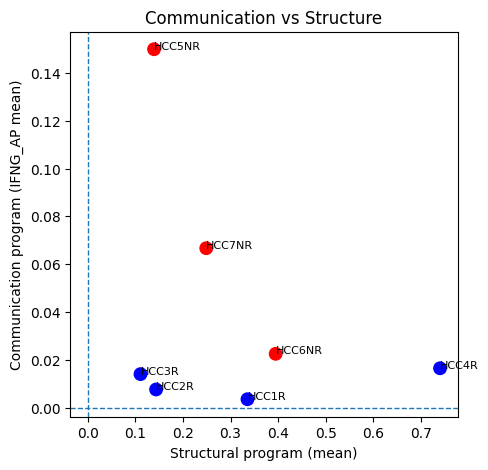

/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_82712/2358401926.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


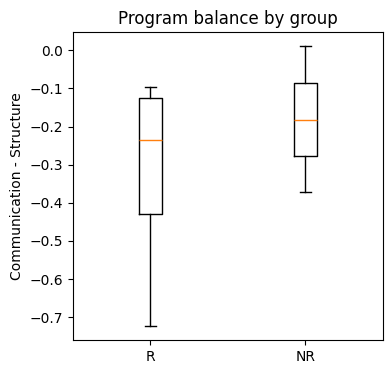

In [84]:
# Cell 14 — Communication vs structure visualization (GSE238264)

import matplotlib.pyplot as plt

df = sample_profile_gse238264.copy()

plt.figure(figsize=(5, 5))
colors = df["group"].map({"R": "blue", "NR": "red"})

plt.scatter(
    df["struct_mean"],
    df["comm_mean_IFNG_AP"],
    c=colors,
    s=80,
)

for _, row in df.iterrows():
    plt.text(
        row["struct_mean"],
        row["comm_mean_IFNG_AP"],
        row["sample_id"],
        fontsize=8
    )

plt.xlabel("Structural program (mean)")
plt.ylabel("Communication program (IFNG_AP mean)")
plt.title("Communication vs Structure")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.show()

plt.figure(figsize=(4, 4))
groups = ["R", "NR"]
data = [df[df["group"] == g]["comm_minus_struct"] for g in groups]
plt.boxplot(data, labels=groups)
plt.ylabel("Communication - Structure")
plt.title("Program balance by group")
plt.show()

### Interpretation
These are the key figures.

They summarize the framework in an application-oriented way:
- one axis reflects communication,
- a set of axes reflects structure,
- the balance between them differentiates the groups directionally.

In [85]:
# Cell 15 — Statistical test for communication–structure balance

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

df = sample_profile_gse238264.copy()

r_vals = df.loc[df["group"] == "R", "comm_minus_struct"].values
nr_vals = df.loc[df["group"] == "NR", "comm_minus_struct"].values

u_stat, p_value = mannwhitneyu(r_vals, nr_vals, alternative="two-sided")

effect_size = float(np.median(nr_vals) - np.median(r_vals))

stats_df = pd.DataFrame(
    {
        "group": ["R", "NR"],
        "n": [len(r_vals), len(nr_vals)],
        "mean": [float(np.mean(r_vals)), float(np.mean(nr_vals))],
        "median": [float(np.median(r_vals)), float(np.median(nr_vals))],
        "std": [float(np.std(r_vals, ddof=1)), float(np.std(nr_vals, ddof=1))],
    }
)

print(stats_df.to_string(index=False))
print(f"\nMann–Whitney U = {u_stat:.3f}")
print(f"p-value = {p_value:.6f}")
print(f"Median(NR) - Median(R) = {effect_size:.6f}")

group  n      mean    median      std
    R  4 -0.322219 -0.234056 0.286950
   NR  3 -0.181393 -0.182353 0.191503

Mann–Whitney U = 5.000
p-value = 0.857143
Median(NR) - Median(R) = 0.051703


### Interpretation
Keep the result honest:

- the effect is directional and interpretable,
- statistical significance is limited by small sample size.

This is still useful because the framework is intended as a mechanistic, interpretable tool, not only as a significance engine.

In [86]:
# Cell 16 — Per-axis contribution to group separation

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

axis_rows = []

for axis in ["TGFB", "SPP1", "VEGF", "CXCL12", "IFNG_AP", "TNF_NFKB", "CSF1R", "WNT", "EGFR"]:
    values = []

    for sample_id, out in prototype_outputs_gse238264_competitive.items():
        axis_names = [p.replace("PROG_COMP_", "") for p in out["program_names"]]
        axis_to_idx = {a: i for i, a in enumerate(axis_names)}

        if axis not in axis_to_idx:
            continue

        v = out["X_program"][:, axis_to_idx[axis]]

        values.append({
            "sample_id": sample_id,
            "group": "NR" if sample_id.endswith("NR") else "R",
            "program_mean": float(np.mean(v)),
            "program_q90": float(np.quantile(v, 0.90)),
        })

    df_axis = pd.DataFrame(values)

    if df_axis["group"].nunique() < 2:
        continue

    r_mean = df_axis[df_axis["group"] == "R"]["program_mean"].values
    nr_mean = df_axis[df_axis["group"] == "NR"]["program_mean"].values

    r_q90 = df_axis[df_axis["group"] == "R"]["program_q90"].values
    nr_q90 = df_axis[df_axis["group"] == "NR"]["program_q90"].values

    _, p_mean = mannwhitneyu(r_mean, nr_mean, alternative="two-sided")
    _, p_q90 = mannwhitneyu(r_q90, nr_q90, alternative="two-sided")

    axis_rows.append({
        "axis": axis,
        "delta_mean_NR_minus_R": float(np.mean(nr_mean) - np.mean(r_mean)),
        "delta_q90_NR_minus_R": float(np.mean(nr_q90) - np.mean(r_q90)),
        "p_mean": float(p_mean),
        "p_q90": float(p_q90)
    })

axis_contrib_gse238264 = pd.DataFrame(axis_rows).sort_values(
    "delta_mean_NR_minus_R", ascending=False
).reset_index(drop=True)

print(axis_contrib_gse238264.to_string(index=False))

    axis  delta_mean_NR_minus_R  delta_q90_NR_minus_R   p_mean    p_q90
    EGFR               0.389644              1.038078 0.057143 0.057143
 IFNG_AP               0.069271              0.190380 0.057143 0.057143
    TGFB               0.053409              0.147929 0.057143 0.057143
TNF_NFKB               0.049046              0.152301 0.228571 0.228571
    VEGF               0.042020              0.119226 0.400000 0.400000
     WNT               0.029910              0.082262 0.057143 0.057143
   CSF1R              -0.039915             -0.114350 0.057143 0.057143
  CXCL12              -0.485670             -1.798657 0.057143 0.057143
    SPP1              -0.754821             -1.343755 0.400000 0.400000


### Main interpretation

The main biological conclusion from GSE238264 is not simply that one communication axis matters.

It is that:

- **IFNG_AP** is the clearest communication-like signal,
- structural programs still dominate much of phenotype separation,
- and outcome is best understood as a **balance between communication and structure**.

This interpretation is what the later datasets are asked to replicate.


# Part II — GSE217414

## Role in the pipeline

GSE217414 is used as a supporting validation dataset.

It is not the main biological endpoint because it does not provide the same response structure as GSE238264. Its role is to test whether the architecture still produces the same separation between communication-like and structure-like behavior in an independent cohort.


In [87]:
# Cell 17 — Load GSE217414

from pathlib import Path
import scanpy as sc
import tarfile
import pandas as pd

BASE = Path("/Users/sally/Desktop/Prototype_validation/GSE217414")

adatas_gse217414 = {}

h5_files = sorted(BASE.glob("*feature_bc_matrix.h5"))

for h5_path in h5_files:
    gsm_id = h5_path.name.split("_")[0]
    print(f"\nLoading {gsm_id}")

    adata = sc.read_10x_h5(h5_path)
    adata.var_names_make_unique()

    spatial_tar = list(BASE.glob(f"{gsm_id}*spatial.tar.gz"))[0]

    extract_dir = BASE / f"_tmp_{gsm_id}"
    extract_dir.mkdir(exist_ok=True)

    with tarfile.open(spatial_tar, "r:gz") as tar:
        tar.extractall(path=extract_dir)

    tissue_files = list(extract_dir.rglob("tissue_positions*.csv"))
    tissue_path = tissue_files[0]
    print("Using:", tissue_path)

    tissue_positions = pd.read_csv(tissue_path, header=None)
    tissue_positions.columns = [
        "barcode", "in_tissue", "array_row", "array_col", "pxl_row", "pxl_col"
    ]
    tissue_positions.set_index("barcode", inplace=True)

    adata_clean = adata.obs_names.str.replace("-1", "", regex=False)
    spatial_clean = tissue_positions.index.str.replace("-1", "", regex=False)

    spatial_lookup = dict(zip(spatial_clean, tissue_positions.values))

    coords = []
    keep_idx = []

    for i, bc in enumerate(adata_clean):
        if bc in spatial_lookup:
            coords.append(spatial_lookup[bc])
            keep_idx.append(i)

    adata = adata[keep_idx].copy()

    coords = pd.DataFrame(coords, columns=tissue_positions.columns)
    adata.obsm["spatial"] = coords[["pxl_row", "pxl_col"]].values

    adata.obs["sample_id"] = gsm_id

    adatas_gse217414[gsm_id] = adata
    print("Final shape:", adata.shape)

print("\nDone.")


Loading GSM6716963


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Using: /Users/sally/Desktop/Prototype_validation/GSE217414/_tmp_GSM6716963/19G081_spatial/tissue_positions_list.csv
Final shape: (2887, 17943)

Loading GSM6716964
Using: /Users/sally/Desktop/Prototype_validation/GSE217414/_tmp_GSM6716964/19G0619_spatial/tissue_positions_list.csv
Final shape: (3379, 17943)

Loading GSM6716965


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Using: /Users/sally/Desktop/Prototype_validation/GSE217414/_tmp_GSM6716965/19G0635_spatial/tissue_positions_list.csv
Final shape: (2091, 17943)

Loading GSM6716966
Using: /Users/sally/Desktop/Prototype_validation/GSE217414/_tmp_GSM6716966/19G02977_spatial/tissue_positions_list.csv
Final shape: (2317, 17943)

Done.


### Interpretation
This loads the second tumor dataset in the format that was debugged during the chat.

In [88]:
# Cell 18 — Normalize GSE217414

import scanpy as sc

adatas_gse217414_norm = {}

for sample_id, adata in adatas_gse217414.items():
    adata = adata.copy()
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adatas_gse217414_norm[sample_id] = adata
    print(sample_id, adata.shape)

GSM6716963 (2887, 17943)
GSM6716964 (3379, 17943)
GSM6716965 (2091, 17943)
GSM6716966 (2317, 17943)


In [89]:
# Cell 19 — Align genes across samples (GSE217414)

common_genes_gse217414 = set(adatas_gse217414_norm[list(adatas_gse217414_norm.keys())[0]].var_names)

for adata in adatas_gse217414_norm.values():
    common_genes_gse217414 = common_genes_gse217414.intersection(set(adata.var_names))

common_genes_gse217414 = sorted(list(common_genes_gse217414))

adatas_gse217414_aligned = {}

for sample_id, adata in adatas_gse217414_norm.items():
    adata_sub = adata[:, common_genes_gse217414].copy()
    adata_sub.var_names_make_unique()
    adatas_gse217414_aligned[sample_id] = adata_sub
    print(sample_id, adata_sub.shape)

print("n_common_genes =", len(common_genes_gse217414))

GSM6716963 (2887, 17943)
GSM6716964 (3379, 17943)
GSM6716965 (2091, 17943)
GSM6716966 (2317, 17943)
n_common_genes = 17943


In [90]:
# Cell 20 — Compute axis programs (GSE217414)

import numpy as np
import pandas as pd

axis_tables_gse217414 = {}
axis_summary_rows_gse217414 = []

for sample_id, adata in adatas_gse217414_aligned.items():
    X = adata.X
    axis_scores = []
    axis_names = []

    for axis, genes in axis_gene_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        if len(genes_present) == 0:
            continue

        idx = [adata.var_names.get_loc(g) for g in genes_present]
        score = X[:, idx]
        if hasattr(score, "toarray"):
            score = score.toarray()
        score = score.mean(axis=1)

        axis_scores.append(score)
        axis_names.append(axis)

        axis_summary_rows_gse217414.append({
            "sample_id": sample_id,
            "axis": axis,
            "n_genes_defined": len(genes),
            "n_genes_present": len(genes_present)
        })

    X_axis = np.vstack(axis_scores).T

    axis_tables_gse217414[sample_id] = {
        "X_axis": X_axis,
        "axis_names": axis_names,
        "obs_names": adata.obs_names,
        "spatial": adata.obsm["spatial"]
    }

    print(sample_id, X_axis.shape)

axis_summary_gse217414 = pd.DataFrame(axis_summary_rows_gse217414)
print(axis_summary_gse217414.to_string(index=False))

GSM6716963 (2887, 9)
GSM6716964 (3379, 9)
GSM6716965 (2091, 9)
GSM6716966 (2317, 9)
 sample_id     axis  n_genes_defined  n_genes_present
GSM6716963     TGFB                7                7
GSM6716963     SPP1                5                5
GSM6716963     VEGF                5                4
GSM6716963   CXCL12                3                2
GSM6716963  IFNG_AP                6                6
GSM6716963 TNF_NFKB                5                5
GSM6716963    CSF1R                2                2
GSM6716963      WNT                5                5
GSM6716963     EGFR                4                4
GSM6716964     TGFB                7                7
GSM6716964     SPP1                5                5
GSM6716964     VEGF                5                4
GSM6716964   CXCL12                3                2
GSM6716964  IFNG_AP                6                6
GSM6716964 TNF_NFKB                5                5
GSM6716964    CSF1R                2                

In [91]:
# Cell 21 — Build spatial neighbors (GSE217414)

import numpy as np
from sklearn.neighbors import NearestNeighbors

spatial_graphs_gse217414 = {}
K = 6

for sample_id, feat in axis_tables_gse217414.items():
    coords = feat["spatial"]

    nbrs = NearestNeighbors(n_neighbors=K + 1).fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    neighbor_idx = indices[:, 1:]

    spatial_graphs_gse217414[sample_id] = {
        "neighbor_indices": neighbor_idx,
        "coords": coords
    }

    print(sample_id, coords.shape, neighbor_idx.shape)

GSM6716963 (2887, 2) (2887, 6)
GSM6716964 (3379, 2) (3379, 6)
GSM6716965 (2091, 2) (2091, 6)
GSM6716966 (2317, 2) (2317, 6)


In [92]:
# Cell 22 — Local + neighbor axis features (GSE217414)

import numpy as np

mixed_axis_features_gse217414 = {}

for sample_id, feat in axis_tables_gse217414.items():
    X_axis = feat["X_axis"]
    nbr_idx = spatial_graphs_gse217414[sample_id]["neighbor_indices"]

    X_local = X_axis.copy()
    X_neighbor = np.zeros_like(X_axis)

    for i in range(X_axis.shape[0]):
        X_neighbor[i] = X_axis[nbr_idx[i]].mean(axis=0)

    mixed_axis_features_gse217414[sample_id] = {
        "X_local_axis": X_local,
        "X_neighbor_axis": X_neighbor,
        "axis_names": feat["axis_names"],
        "obs_names": feat["obs_names"],
        "spatial": feat["spatial"]
    }

    print(sample_id, X_local.shape, X_neighbor.shape)

GSM6716963 (2887, 9) (2887, 9)
GSM6716964 (3379, 9) (3379, 9)
GSM6716965 (2091, 9) (2091, 9)
GSM6716966 (2317, 9) (2317, 9)


In [93]:
# Cell 23 — Competitive gating (GSE217414)

import numpy as np

TAU = 2.0
prototype_outputs_gse217414_competitive = {}

for sample_id, obj in mixed_axis_features_gse217414.items():
    X_local = obj["X_local_axis"].astype(np.float32)
    X_neighbor = obj["X_neighbor_axis"].astype(np.float32)
    axis_names = list(obj["axis_names"])

    logits = TAU * X_local
    logits = logits - logits.max(axis=1, keepdims=True)

    exp_logits = np.exp(logits)
    gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

    X_program = gate * X_neighbor

    prototype_outputs_gse217414_competitive[sample_id] = {
        "X_program": X_program,
        "program_names": np.array([f"PROG_COMP_{a}" for a in axis_names], dtype=object),
        "obs_names": obj["obs_names"]
    }

    print(sample_id, X_program.shape)

GSM6716963 (2887, 9)
GSM6716964 (3379, 9)
GSM6716965 (2091, 9)
GSM6716966 (2317, 9)


In [94]:
# Cell 24 — Identifiability (GSE217414)

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

identifiability_rows_gse217414 = []

for sample_id, obj in mixed_axis_features_gse217414.items():
    X_local = obj["X_local_axis"]
    axis_names = obj["axis_names"]

    X_program = prototype_outputs_gse217414_competitive[sample_id]["X_program"]

    for j, axis in enumerate(axis_names):
        y = X_local[:, j]

        model = LinearRegression()
        model.fit(X_program, y)
        y_pred = model.predict(X_program)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2) + 1e-8
        r2 = 1 - ss_res / ss_tot

        identifiability_rows_gse217414.append({
            "sample_id": sample_id,
            "axis": axis,
            "r2_local_reconstruction": float(r2)
        })

identifiability_gse217414 = pd.DataFrame(identifiability_rows_gse217414)
print(identifiability_gse217414.to_string(index=False))

 sample_id     axis  r2_local_reconstruction
GSM6716963     TGFB                 0.494958
GSM6716963     SPP1                 0.689550
GSM6716963     VEGF                 0.460706
GSM6716963   CXCL12                 0.319508
GSM6716963  IFNG_AP                 0.138370
GSM6716963 TNF_NFKB                 0.708871
GSM6716963    CSF1R                 0.380058
GSM6716963      WNT                 0.499290
GSM6716963     EGFR                 0.517057
GSM6716964     TGFB                 0.170966
GSM6716964     SPP1                 0.423503
GSM6716964     VEGF                 0.102286
GSM6716964   CXCL12                 0.501713
GSM6716964  IFNG_AP                 0.038071
GSM6716964 TNF_NFKB                 0.485211
GSM6716964    CSF1R                 0.310724
GSM6716964      WNT                 0.438321
GSM6716964     EGFR                 0.138715
GSM6716965     TGFB                 0.603488
GSM6716965     SPP1                 0.785922
GSM6716965     VEGF                 0.643483
GSM6716965

### Main interpretation

GSE217414 preserves the architectural pattern observed in the main dataset:

- some axes remain weakly reconstructable,
- some remain more locally reconstructable,
- and the role separation is not lost in a second tumor cohort.

The important retained point is that **IFNG_AP** again falls on the communication-like side of the decomposition.


In [95]:
# Cell 25 — Axis summary (GSE217414)

axis_ident_summary_gse217414 = (
    identifiability_gse217414.groupby("axis")["r2_local_reconstruction"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean")
)

print(axis_ident_summary_gse217414.to_string())

              mean    median       min       max
axis                                            
IFNG_AP   0.098330  0.090085  0.038071  0.175078
CSF1R     0.295381  0.279658  0.242151  0.380058
CXCL12    0.331065  0.308650  0.205246  0.501713
VEGF      0.357640  0.342396  0.102286  0.643483
TGFB      0.360955  0.334683  0.170966  0.603488
EGFR      0.425169  0.414066  0.138715  0.733829
WNT       0.495692  0.502700  0.438321  0.539048
SPP1      0.588854  0.572996  0.423503  0.785922
TNF_NFKB  0.618685  0.640330  0.485211  0.708871


In [96]:
# Cell 26 — Spatial smoothness (GSE217414)

import numpy as np
import pandas as pd

smoothness_rows_gse217414 = []

for sample_id, out in prototype_outputs_gse217414_competitive.items():
    nbr_idx = spatial_graphs_gse217414[sample_id]["neighbor_indices"]
    program_names = list(out["program_names"])
    X_program = out["X_program"]

    for j, pname in enumerate(program_names):
        axis = pname.replace("PROG_COMP_", "")

        prog = X_program[:, j]
        nbr_mean = np.array([prog[nbr_idx[i]].mean() for i in range(len(prog))])

        corr = np.corrcoef(prog, nbr_mean)[0, 1]
        mse = np.mean((prog - nbr_mean) ** 2)

        smoothness_rows_gse217414.append({
            "sample_id": sample_id,
            "axis": axis,
            "neighbor_corr": float(corr),
            "neighbor_mse": float(mse),
            "program_std": float(np.std(prog))
        })

spatial_smoothness_gse217414 = pd.DataFrame(smoothness_rows_gse217414)
print(spatial_smoothness_gse217414.to_string(index=False))

 sample_id     axis  neighbor_corr  neighbor_mse  program_std
GSM6716963     TGFB       0.774075      0.000074     0.013525
GSM6716963     SPP1       0.716894      0.002478     0.071400
GSM6716963     VEGF       0.770133      0.000161     0.019731
GSM6716963   CXCL12       0.791890      0.000777     0.045499
GSM6716963  IFNG_AP       0.775483      0.000006     0.003961
GSM6716963 TNF_NFKB       0.682687      0.003264     0.078182
GSM6716963    CSF1R       0.671894      0.000310     0.023743
GSM6716963      WNT       0.509640      0.001593     0.046198
GSM6716963     EGFR       0.798030      0.000314     0.029256
GSM6716964     TGFB       0.729268      0.000032     0.008272
GSM6716964     SPP1       0.708449      0.000447     0.029799
GSM6716964     VEGF       0.695927      0.000036     0.008364
GSM6716964   CXCL12       0.722188      0.004095     0.091600
GSM6716964  IFNG_AP       0.619354      0.000008     0.003539
GSM6716964 TNF_NFKB       0.729421      0.000718     0.038959
GSM67169

### Main interpretation

This section reinforces the same methodological point on an independent dataset:

many axes can be spatially smooth, but only a subset are truly informative as context-dependent programs.

In other words, the architecture continues to distinguish:

- smoothness,
- dependence,
- and local reconstructability.


In [97]:
# Cell 27 — Inspect metadata (GSE217414)

for sample_id, adata in adatas_gse217414.items():
    print(f"\n=== {sample_id} ===")
    print("\nobs columns:")
    print(list(adata.obs.columns))
    print("\nobs head:")
    print(adata.obs.head())
    print("\nuns keys:")
    print(list(adata.uns.keys()))
    print("\nvar columns:")
    print(list(adata.var.columns))


=== GSM6716963 ===

obs columns:
['sample_id']

obs head:
                     sample_id
AAACAAGTATCTCCCA-1  GSM6716963
AAACACCAATAACTGC-1  GSM6716963
AAACAGAGCGACTCCT-1  GSM6716963
AAACATTTCCCGGATT-1  GSM6716963
AAACCGGGTAGGTACC-1  GSM6716963

uns keys:
[]

var columns:
['gene_ids', 'feature_types', 'genome']

=== GSM6716964 ===

obs columns:
['sample_id']

obs head:
                     sample_id
AAACAAGTATCTCCCA-1  GSM6716964
AAACAATCTACTAGCA-1  GSM6716964
AAACAGAGCGACTCCT-1  GSM6716964
AAACATTTCCCGGATT-1  GSM6716964
AAACCACTACACAGAT-1  GSM6716964

uns keys:
[]

var columns:
['gene_ids', 'feature_types', 'genome']

=== GSM6716965 ===

obs columns:
['sample_id']

obs head:
                     sample_id
AAACAAGTATCTCCCA-1  GSM6716965
AAACACCAATAACTGC-1  GSM6716965
AAACAGGGTCTATATT-1  GSM6716965
AAACATTTCCCGGATT-1  GSM6716965
AAACCCGAACGAAATC-1  GSM6716965

uns keys:
[]

var columns:
['gene_ids', 'feature_types', 'genome']

=== GSM6716966 ===

obs columns:
['sample_id']

obs head:
  

### Interpretation

The metadata check is kept because it justifies how GSE217414 is used.

The dataset is informative for **architectural replication**, but it does not support the same response-oriented application as GSE238264. That distinction keeps the pipeline honest.


In [98]:
# Cell 28 — Cluster program representations (GSE217414)

import numpy as np
from sklearn.cluster import KMeans

program_clusters_gse217414 = {}
K = 5

for sample_id, out in prototype_outputs_gse217414_competitive.items():
    X = out["X_program"]

    km = KMeans(n_clusters=K, random_state=0, n_init=10)
    labels = km.fit_predict(X)

    program_clusters_gse217414[sample_id] = labels
    print(sample_id, "clusters:", np.bincount(labels))

GSM6716963 clusters: [701 661 771  10 744]
GSM6716964 clusters: [ 378   95 2186   95  625]
GSM6716965 clusters: [672 358 100 372 589]
GSM6716966 clusters: [ 544 1161  136   48  428]


In [99]:
# Cell 29 — Dominant program per cluster (GSE217414)

import pandas as pd

dominant_rows_gse217414 = []

for sample_id, out in prototype_outputs_gse217414_competitive.items():
    X = out["X_program"]
    program_names = out["program_names"]
    labels = program_clusters_gse217414[sample_id]

    for k in range(labels.max() + 1):
        idx = labels == k
        if idx.sum() == 0:
            continue

        mean_profile = X[idx].mean(axis=0)
        j_max = mean_profile.argmax()
        dominant_program = program_names[j_max]
        dominant_value = mean_profile[j_max]

        dominant_rows_gse217414.append({
            "sample_id": sample_id,
            "cluster": int(k),
            "size": int(idx.sum()),
            "dominant_program": dominant_program,
            "dominant_value": float(dominant_value)
        })

dominant_df_gse217414 = pd.DataFrame(dominant_rows_gse217414)
print(dominant_df_gse217414.sort_values(["sample_id", "cluster"]).to_string(index=False))

 sample_id  cluster  size   dominant_program  dominant_value
GSM6716963        0   701      PROG_COMP_WNT        0.079162
GSM6716963        1   661     PROG_COMP_SPP1        0.196647
GSM6716963        2   771      PROG_COMP_WNT        0.163296
GSM6716963        3    10   PROG_COMP_CXCL12        0.624509
GSM6716963        4   744 PROG_COMP_TNF_NFKB        0.216499
GSM6716964        0   378   PROG_COMP_CXCL12        0.193082
GSM6716964        1    95   PROG_COMP_CXCL12        0.443240
GSM6716964        2  2186      PROG_COMP_WNT        0.031356
GSM6716964        3    95    PROG_COMP_CSF1R        0.166631
GSM6716964        4   625      PROG_COMP_WNT        0.103537
GSM6716965        0   672     PROG_COMP_SPP1        0.257455
GSM6716965        1   358     PROG_COMP_EGFR        0.185432
GSM6716965        2   100     PROG_COMP_SPP1        0.619977
GSM6716965        3   372     PROG_COMP_SPP1        0.402483
GSM6716965        4   589     PROG_COMP_SPP1        0.119341
GSM6716966        0   54

### Interpretation

This section keeps the ecological-program view of the supporting dataset.

The retained observation is that tumors are not organized by a single homogeneous mode. Instead, they contain a mixture of:

- broad structural regions,
- inflammatory / structural domains,
- and smaller niche-like programs.

That is consistent with the framework's goal of interpretable spatial program discovery.


# Part III — GSE235672

## Role in the validation pipeline

GSE235672 contributes two complementary forms of validation.

### 1. Neoadjuvant anti-PD-1 subset
Used for an independent response-oriented check with responder / non-responder labels derived from the paper supplement.

### 2. ND/Rec subset
Used for a label-free test of whether the same communication–structure decomposition still describes baseline tumor organization.

Together, these two views make GSE235672 especially useful: it tests the framework both **with** and **without** phenotype labels.


In [100]:
# Cell 30 — Check GSE235672 file structure (supports h5 + mtx)

from pathlib import Path
from collections import defaultdict
import pandas as pd
import re

BASE_GSE235672 = Path("/Users/sally/Desktop/Prototype_validation/GSE235672")

if not BASE_GSE235672.exists():
    raise FileNotFoundError(f"Dataset directory not found: {BASE_GSE235672}")

all_files_gse235672 = sorted([p for p in BASE_GSE235672.iterdir() if p.is_file()])
print(f"BASE: {BASE_GSE235672}")
print(f"Total files: {len(all_files_gse235672)}\n")

sample_files_gse235672 = defaultdict(list)
for p in all_files_gse235672:
    m = re.match(r"(GSM\d+)", p.name)
    if m:
        sample_files_gse235672[m.group(1)].append(p.name)

required_patterns_gse235672 = {
    "has_h5": r"filtered_feature_bc_matrix\.h5$",
    "has_mtx": r"matrix\.mtx\.gz$",
    "has_barcodes": r"barcodes\.tsv\.gz$",
    "has_features": r"features\.tsv\.gz$",
    "tissue_positions": r"tissue_positions_list\.csv\.gz$",
    "scalefactors": r"scalefactors_json\.json\.gz$",
    "hires_image": r"tissue_hires_image\.png\.gz$",
    "lowres_image": r"tissue_lowres_image\.png\.gz$",
}

summary_rows_gse235672 = []

for gsm_id in sorted(sample_files_gse235672):
    names = sample_files_gse235672[gsm_id]
    row = {"gsm_id": gsm_id, "n_files": len(names)}

    for key, pattern in required_patterns_gse235672.items():
        row[key] = any(re.search(pattern, name) for name in names)

    row["has_expression"] = row["has_h5"] or (
        row["has_mtx"] and row["has_barcodes"] and row["has_features"]
    )
    summary_rows_gse235672.append(row)

structure_df_gse235672 = pd.DataFrame(summary_rows_gse235672).sort_values("gsm_id").reset_index(drop=True)
display(structure_df_gse235672)

missing_any_gse235672 = structure_df_gse235672.loc[
    ~(
        structure_df_gse235672["has_expression"]
        & structure_df_gse235672["tissue_positions"]
        & structure_df_gse235672["scalefactors"]
    )
]

if len(missing_any_gse235672) > 0:
    display(missing_any_gse235672)
    raise ValueError("GSE235672 structure check failed for one or more samples.")

print(f"\nDetected {len(structure_df_gse235672)} samples.")
print("Structure check passed.")


BASE: /Users/sally/Desktop/Prototype_validation/GSE235672
Total files: 148



,gsm_id,n_files,has_h5,has_mtx,has_barcodes,has_features,tissue_positions,scalefactors,hires_image,lowres_image,has_expression
0,GSM7507311,7,True,False,False,False,True,True,True,True,True
1,GSM7507312,7,True,False,False,False,True,True,True,True,True
2,GSM7507313,7,True,False,False,False,True,True,True,True,True
3,GSM7507314,7,True,False,False,False,True,True,True,True,True
4,GSM7507315,7,True,False,False,False,True,True,True,True,True
5,GSM7507316,7,True,False,False,False,True,True,True,True,True
6,GSM7507317,7,True,False,False,False,True,True,True,True,True
7,GSM7507318,7,True,False,False,False,True,True,True,True,True
8,GSM7507319,7,True,False,False,False,True,True,True,True,True
9,GSM7507320,7,True,False,False,False,True,True,True,True,True



Detected 20 samples.
Structure check passed.


In [101]:
# Cell 31 — Load GSE235672 AnnData objects (all 20 samples; h5 + mtx)

import scanpy as sc
import pandas as pd
import numpy as np

all_gsms_gse235672 = sorted({p.name.split("_")[0] for p in BASE_GSE235672.glob("GSM*")})
adatas_gse235672 = {}

print(f"Detected GSM samples: {len(all_gsms_gse235672)}\n")

for gsm in all_gsms_gse235672:
    h5_files = list(BASE_GSE235672.glob(f"{gsm}*_filtered_feature_bc_matrix.h5"))
    mtx_files = list(BASE_GSE235672.glob(f"{gsm}*_matrix.mtx.gz"))

    if len(h5_files) > 0:
        adata = sc.read_10x_h5(h5_files[0])
    elif len(mtx_files) > 0:
        mtx_path = mtx_files[0]
        prefix = mtx_path.name.replace("matrix.mtx.gz", "")
        adata = sc.read_10x_mtx(
            path=BASE_GSE235672,
            prefix=prefix,
            var_names="gene_symbols",
            cache=False
        )
    else:
        raise FileNotFoundError(f"No expression matrix found for {gsm}")

    adata.var_names = adata.var_names.astype(str).str.upper()
    adata.var_names_make_unique()

    pos_path = list(BASE_GSE235672.glob(f"{gsm}*_tissue_positions_list.csv.gz"))
    if len(pos_path) == 0:
        raise FileNotFoundError(f"No tissue_positions_list found for {gsm}")
    pos_path = pos_path[0]

    pos = pd.read_csv(pos_path, header=None)
    pos.columns = ["barcode", "in_tissue", "array_row", "array_col", "pxl_row", "pxl_col"]
    pos["barcode"] = pos["barcode"].astype(str)
    pos = pos.set_index("barcode")

    adata.obs_names = adata.obs_names.astype(str)
    adata.obs = adata.obs.join(pos, how="left")

    if adata.obs[["pxl_row", "pxl_col"]].isna().any().any():
        missing = int(adata.obs["pxl_row"].isna().sum())
        raise ValueError(f"{gsm}: {missing} spots missing spatial coordinates after join")

    adata.obsm["spatial"] = adata.obs[["pxl_row", "pxl_col"]].to_numpy(dtype=float)
    adata.obs["sample_id"] = gsm

    adatas_gse235672[gsm] = adata
    print(f"{gsm}: {adata.shape}")

print(f"\nLoaded {len(adatas_gse235672)} samples.")


Detected GSM samples: 20



/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


GSM7507311: (2587, 33538)


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


GSM7507312: (1883, 33538)


...

GSM7507324: (1887, 33538)


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


GSM7507325: (2578, 33538)


/Users/sally/miniforge3/envs/gnn-pyg/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


GSM7507326: (1948, 33538)
GSM7507327: (2149, 33538)
GSM7507328: (2897, 33538)
GSM7507329: (2320, 33538)
GSM7507330: (2751, 33538)

Loaded 20 samples.


### Interpretation

All **20 spatial samples** are retained once both expression formats are supported:

- `filtered_feature_bc_matrix.h5`
- `matrix.mtx.gz + barcodes.tsv.gz + features.tsv.gz`

This keeps the entry point at the raw-count level and preserves the same preprocessing logic used elsewhere in the notebook.


In [102]:
# Cell 32 — Normalize GSE235672

import scanpy as sc

adatas_gse235672_norm = {}

for sample_id, adata in adatas_gse235672.items():
    adata = adata.copy()
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adatas_gse235672_norm[sample_id] = adata
    print(sample_id, adata.shape)


GSM7507311 (2587, 33538)
GSM7507312 (1883, 33538)
GSM7507313 (1876, 33538)
GSM7507314 (2963, 33538)
GSM7507315 (1858, 36601)
GSM7507316 (2560, 33538)
GSM7507317 (2027, 33538)
GSM7507318 (1555, 36601)
GSM7507319 (1733, 36601)
GSM7507320 (2253, 36601)
GSM7507321 (2176, 33538)
GSM7507322 (2494, 33538)
GSM7507323 (2499, 33538)
GSM7507324 (1887, 33538)
GSM7507325 (2578, 33538)
GSM7507326 (1948, 33538)
GSM7507327 (2149, 33538)
GSM7507328 (2897, 33538)
GSM7507329 (2320, 33538)
GSM7507330 (2751, 33538)


In [103]:
# Cell 33 — Align genes across samples (GSE235672)

common_genes_gse235672 = set(adatas_gse235672_norm[list(adatas_gse235672_norm.keys())[0]].var_names)

for adata in adatas_gse235672_norm.values():
    common_genes_gse235672 = common_genes_gse235672.intersection(set(adata.var_names))

common_genes_gse235672 = sorted(list(common_genes_gse235672))

adatas_gse235672_aligned = {}

for sample_id, adata in adatas_gse235672_norm.items():
    adata_sub = adata[:, common_genes_gse235672].copy()
    adata_sub.var_names_make_unique()
    adatas_gse235672_aligned[sample_id] = adata_sub
    print(sample_id, adata_sub.shape)

print("n_common_genes =", len(common_genes_gse235672))


GSM7507311 (2587, 31915)
GSM7507312 (1883, 31915)
GSM7507313 (1876, 31915)
GSM7507314 (2963, 31915)
GSM7507315 (1858, 31915)
GSM7507316 (2560, 31915)
GSM7507317 (2027, 31915)
GSM7507318 (1555, 31915)
GSM7507319 (1733, 31915)
GSM7507320 (2253, 31915)
GSM7507321 (2176, 31915)
GSM7507322 (2494, 31915)
GSM7507323 (2499, 31915)
GSM7507324 (1887, 31915)
GSM7507325 (2578, 31915)
GSM7507326 (1948, 31915)
GSM7507327 (2149, 31915)
GSM7507328 (2897, 31915)
GSM7507329 (2320, 31915)
GSM7507330 (2751, 31915)
n_common_genes = 31915


### Interpretation

Gene alignment keeps the biological axes fixed across all GSE235672 samples.

This matters because validation here means testing the same prior on a new dataset, not redefining the prior to fit the new dataset.


In [104]:
# Cell 34 — Compute axis programs (GSE235672)

import numpy as np
import pandas as pd

axis_tables_gse235672 = {}
axis_summary_rows_gse235672 = []

for sample_id, adata in adatas_gse235672_aligned.items():
    X = adata.X
    axis_scores = []
    axis_names = []

    for axis, genes in axis_gene_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        if len(genes_present) == 0:
            continue

        idx = [adata.var_names.get_loc(g) for g in genes_present]
        score = X[:, idx]
        if hasattr(score, "toarray"):
            score = score.toarray()
        score = np.asarray(score).mean(axis=1)

        axis_scores.append(score)
        axis_names.append(axis)

        axis_summary_rows_gse235672.append({
            "sample_id": sample_id,
            "axis": axis,
            "n_genes_defined": len(genes),
            "n_genes_present": len(genes_present)
        })

    X_axis = np.vstack(axis_scores).T

    axis_tables_gse235672[sample_id] = {
        "X_axis": X_axis,
        "axis_names": axis_names,
        "obs_names": adata.obs_names.copy(),
        "spatial": np.asarray(adata.obsm["spatial"])
    }

    print(sample_id, X_axis.shape)

axis_summary_gse235672 = pd.DataFrame(axis_summary_rows_gse235672)
print("\nAxis coverage summary:")
print(axis_summary_gse235672.to_string(index=False))


GSM7507311 (2587, 9)
GSM7507312 (1883, 9)
GSM7507313 (1876, 9)
GSM7507314 (2963, 9)
GSM7507315 (1858, 9)
GSM7507316 (2560, 9)
GSM7507317 (2027, 9)
GSM7507318 (1555, 9)
GSM7507319 (1733, 9)
GSM7507320 (2253, 9)
GSM7507321 (2176, 9)
GSM7507322 (2494, 9)
GSM7507323 (2499, 9)
GSM7507324 (1887, 9)
GSM7507325 (2578, 9)
GSM7507326 (1948, 9)
GSM7507327 (2149, 9)
GSM7507328 (2897, 9)
GSM7507329 (2320, 9)
GSM7507330 (2751, 9)

Axis coverage summary:
 sample_id     axis  n_genes_defined  n_genes_present
GSM7507311     TGFB                7                7
GSM7507311     SPP1                5                5
GSM7507311     VEGF                5                5
GSM7507311   CXCL12                3                2
GSM7507311  IFNG_AP                6                6
GSM7507311 TNF_NFKB                5                5
GSM7507311    CSF1R                2                2
GSM7507311      WNT                5                5
GSM7507311     EGFR                4                4
GSM7507312     T

In [105]:
# Cell 35 — Build spatial neighbors (GSE235672)

import numpy as np
from sklearn.neighbors import NearestNeighbors

spatial_graphs_gse235672 = {}
K = 6

for sample_id, feat in axis_tables_gse235672.items():
    coords = feat["spatial"]

    nbrs = NearestNeighbors(n_neighbors=K + 1).fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    neighbor_idx = indices[:, 1:]

    spatial_graphs_gse235672[sample_id] = {
        "neighbor_indices": neighbor_idx,
        "coords": coords
    }

    print(sample_id, coords.shape, neighbor_idx.shape)


GSM7507311 (2587, 2) (2587, 6)
GSM7507312 (1883, 2) (1883, 6)
GSM7507313 (1876, 2) (1876, 6)
GSM7507314 (2963, 2) (2963, 6)
GSM7507315 (1858, 2) (1858, 6)
GSM7507316 (2560, 2) (2560, 6)
GSM7507317 (2027, 2) (2027, 6)
GSM7507318 (1555, 2) (1555, 6)
GSM7507319 (1733, 2) (1733, 6)
GSM7507320 (2253, 2) (2253, 6)
GSM7507321 (2176, 2) (2176, 6)
GSM7507322 (2494, 2) (2494, 6)
GSM7507323 (2499, 2) (2499, 6)
GSM7507324 (1887, 2) (1887, 6)
GSM7507325 (2578, 2) (2578, 6)
GSM7507326 (1948, 2) (1948, 6)
GSM7507327 (2149, 2) (2149, 6)
GSM7507328 (2897, 2) (2897, 6)
GSM7507329 (2320, 2) (2320, 6)
GSM7507330 (2751, 2) (2751, 6)


In [106]:
# Cell 36 — Local + neighbor axis features (GSE235672)

import numpy as np

mixed_axis_features_gse235672 = {}

for sample_id, feat in axis_tables_gse235672.items():
    X_axis = feat["X_axis"]
    nbr_idx = spatial_graphs_gse235672[sample_id]["neighbor_indices"]

    X_local = X_axis.copy()
    X_neighbor = np.zeros_like(X_axis)

    for i in range(X_axis.shape[0]):
        X_neighbor[i] = X_axis[nbr_idx[i]].mean(axis=0)

    mixed_axis_features_gse235672[sample_id] = {
        "X_local_axis": X_local,
        "X_neighbor_axis": X_neighbor,
        "axis_names": feat["axis_names"],
        "obs_names": feat["obs_names"],
        "spatial": feat["spatial"]
    }

    print(sample_id, X_local.shape, X_neighbor.shape)


GSM7507311 (2587, 9) (2587, 9)
GSM7507312 (1883, 9) (1883, 9)
GSM7507313 (1876, 9) (1876, 9)
GSM7507314 (2963, 9) (2963, 9)
GSM7507315 (1858, 9) (1858, 9)
GSM7507316 (2560, 9) (2560, 9)
GSM7507317 (2027, 9) (2027, 9)
GSM7507318 (1555, 9) (1555, 9)
GSM7507319 (1733, 9) (1733, 9)
GSM7507320 (2253, 9) (2253, 9)
GSM7507321 (2176, 9) (2176, 9)
GSM7507322 (2494, 9) (2494, 9)
GSM7507323 (2499, 9) (2499, 9)
GSM7507324 (1887, 9) (1887, 9)
GSM7507325 (2578, 9) (2578, 9)
GSM7507326 (1948, 9) (1948, 9)
GSM7507327 (2149, 9) (2149, 9)
GSM7507328 (2897, 9) (2897, 9)
GSM7507329 (2320, 9) (2320, 9)
GSM7507330 (2751, 9) (2751, 9)


In [107]:
# Cell 37 — Competitive gating architecture (GSE235672)

import numpy as np

TAU = 2.0
prototype_outputs_gse235672_competitive = {}

for sample_id, obj in mixed_axis_features_gse235672.items():
    X_local = obj["X_local_axis"].astype(np.float32)
    X_neighbor = obj["X_neighbor_axis"].astype(np.float32)
    axis_names = list(obj["axis_names"])

    logits = TAU * X_local
    logits = logits - logits.max(axis=1, keepdims=True)

    exp_logits = np.exp(logits)
    gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

    X_program = gate * X_neighbor

    prototype_outputs_gse235672_competitive[sample_id] = {
        "X_program": X_program,
        "program_names": np.array([f"PROG_COMP_{a}" for a in axis_names], dtype=object),
        "obs_names": obj["obs_names"],
        "X_gate": gate
    }

    print(sample_id, X_program.shape)


GSM7507311 (2587, 9)
GSM7507312 (1883, 9)
GSM7507313 (1876, 9)
GSM7507314 (2963, 9)
GSM7507315 (1858, 9)
GSM7507316 (2560, 9)
GSM7507317 (2027, 9)
GSM7507318 (1555, 9)
GSM7507319 (1733, 9)
GSM7507320 (2253, 9)
GSM7507321 (2176, 9)
GSM7507322 (2494, 9)
GSM7507323 (2499, 9)
GSM7507324 (1887, 9)
GSM7507325 (2578, 9)
GSM7507326 (1948, 9)
GSM7507327 (2149, 9)
GSM7507328 (2897, 9)
GSM7507329 (2320, 9)
GSM7507330 (2751, 9)


### Main architectural note

The architecture is unchanged:

**Program = softmax(τ · local axis) ⊙ neighbor axis**

GSE235672 is therefore a genuine validation dataset.  
Only the data source changes; the model, definitions, and interpretation stay fixed.


In [108]:
# Cell 38 — Identifiability (GSE235672)

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

identifiability_rows_gse235672 = []

for sample_id, out in prototype_outputs_gse235672_competitive.items():
    X_local = mixed_axis_features_gse235672[sample_id]["X_local_axis"]
    Y_prog = out["X_program"]
    axis_names = mixed_axis_features_gse235672[sample_id]["axis_names"]

    for j, axis in enumerate(axis_names):
        y = Y_prog[:, j]
        model = LinearRegression()
        model.fit(X_local, y)
        y_hat = model.predict(X_local)
        r2 = r2_score(y, y_hat)

        identifiability_rows_gse235672.append({
            "sample_id": sample_id,
            "axis": axis,
            "r2_local_reconstruction": float(r2)
        })

identifiability_gse235672 = pd.DataFrame(identifiability_rows_gse235672)
print(identifiability_gse235672.to_string(index=False))


 sample_id     axis  r2_local_reconstruction
GSM7507311     TGFB                 0.395089
GSM7507311     SPP1                 0.817496
GSM7507311     VEGF                 0.532026
GSM7507311   CXCL12                 0.524072
GSM7507311  IFNG_AP                 0.410938
GSM7507311 TNF_NFKB                 0.407678
GSM7507311    CSF1R                 0.527515
GSM7507311      WNT                 0.414793
GSM7507311     EGFR                 0.539142
GSM7507312     TGFB                 0.578357
GSM7507312     SPP1                 0.859900
GSM7507312     VEGF                 0.708446
GSM7507312   CXCL12                 0.648079
GSM7507312  IFNG_AP                 0.370146
GSM7507312 TNF_NFKB                 0.634615
GSM7507312    CSF1R                 0.642432
GSM7507312      WNT                 0.622079
GSM7507312     EGFR                 0.696408
GSM7507313     TGFB                 0.624227
GSM7507313     SPP1                 0.914839
GSM7507313     VEGF                 0.613565
GSM7507313

In [109]:
# Cell 39 — Axis summary (GSE235672)

axis_ident_summary_gse235672 = (
    identifiability_gse235672.groupby("axis")["r2_local_reconstruction"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(axis_ident_summary_gse235672.to_string())


              mean       std
axis                        
SPP1      0.836435  0.070144
EGFR      0.638286  0.114410
WNT       0.586777  0.120714
CSF1R     0.574769  0.131440
VEGF      0.572668  0.129457
TGFB      0.552428  0.096681
TNF_NFKB  0.484988  0.111103
CXCL12    0.439736  0.142414
IFNG_AP   0.419119  0.134272


### Interpretation

The identifiability pattern is preserved in GSE235672:

- **SPP1** remains the clearest structure-like axis with the highest local reconstructability
- **IFNG_AP** remains lower-R² and therefore communication-like
- the remaining axes stay in the lower-R² range and continue to support the same communication–structure decomposition

This is one of the strongest cross-dataset consistency checks in the notebook.


In [110]:
# Cell 40 — Spatial smoothness (GSE235672)

import numpy as np
import pandas as pd

smoothness_rows_gse235672 = []

for sample_id, obj in mixed_axis_features_gse235672.items():
    X_local = obj["X_local_axis"]
    X_neighbor = obj["X_neighbor_axis"]
    axis_names = obj["axis_names"]

    for j, axis in enumerate(axis_names):
        x = X_local[:, j]
        xn = X_neighbor[:, j]

        if np.std(x) == 0 or np.std(xn) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(x, xn)[0, 1]

        smoothness_rows_gse235672.append({
            "sample_id": sample_id,
            "axis": axis,
            "neighbor_correlation": float(corr)
        })

smoothness_gse235672 = pd.DataFrame(smoothness_rows_gse235672)
print(smoothness_gse235672.to_string(index=False))


 sample_id     axis  neighbor_correlation
GSM7507311     TGFB              0.256286
GSM7507311     SPP1              0.600733
GSM7507311     VEGF              0.546479
GSM7507311   CXCL12              0.374472
GSM7507311  IFNG_AP              0.487838
GSM7507311 TNF_NFKB              0.276597
GSM7507311    CSF1R              0.246456
GSM7507311      WNT              0.290750
GSM7507311     EGFR              0.134899
GSM7507312     TGFB              0.246400
GSM7507312     SPP1              0.347073
GSM7507312     VEGF              0.517172
GSM7507312   CXCL12              0.369817
GSM7507312  IFNG_AP              0.538515
GSM7507312 TNF_NFKB              0.060508
GSM7507312    CSF1R              0.217249
GSM7507312      WNT              0.260597
GSM7507312     EGFR              0.178067
GSM7507313     TGFB              0.229756
GSM7507313     SPP1              0.850096
GSM7507313     VEGF              0.672955
GSM7507313   CXCL12              0.145581
GSM7507313  IFNG_AP              0

In [111]:
# Cell 41 — Smoothness summary (GSE235672)

smoothness_summary_gse235672 = (
    smoothness_gse235672.groupby("axis")["neighbor_correlation"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(smoothness_summary_gse235672.to_string())


              mean       std
axis                        
SPP1      0.579757  0.143525
VEGF      0.461093  0.184909
IFNG_AP   0.457125  0.135235
TGFB      0.291101  0.144507
CXCL12    0.271716  0.150967
EGFR      0.265554  0.185621
WNT       0.250991  0.147414
CSF1R     0.240563  0.148694
TNF_NFKB  0.233289  0.143486


### Interpretation

GSE235672 again shows that **smoothness is not the same as dependence**.

In particular, **IFNG_AP** can remain spatially smooth while still showing low identifiability. That is the expected pattern for a communication-like program whose meaning depends on context rather than on local state alone.


In [112]:
# Cell 42 — Communication vs structure summary per sample (GSE235672)

import numpy as np
import pandas as pd

sample_scores_gse235672 = []

for sample_id, obj in mixed_axis_features_gse235672.items():
    X_local = obj["X_local_axis"]
    axis_names = obj["axis_names"]

    axis_idx = {a: i for i, a in enumerate(axis_names)}

    communication = X_local[:, axis_idx["IFNG_AP"]]
    spp1 = X_local[:, axis_idx["SPP1"]]
    wnt = X_local[:, axis_idx["WNT"]]
    tnf = X_local[:, axis_idx["TNF_NFKB"]]
    egfr = X_local[:, axis_idx["EGFR"]]

    structure = (spp1 + wnt + tnf + egfr) / 4.0
    comm_minus_struct = communication - structure

    sample_scores_gse235672.append({
        "sample_id": sample_id,
        "communication_mean": float(np.mean(communication)),
        "structure_mean": float(np.mean(structure)),
        "comm_minus_struct": float(np.mean(comm_minus_struct)),
    })

sample_scores_gse235672 = pd.DataFrame(sample_scores_gse235672)
print(sample_scores_gse235672.to_string(index=False))


 sample_id  communication_mean  structure_mean  comm_minus_struct
GSM7507311            0.122941        0.420529          -0.297588
GSM7507312            0.152128        0.648610          -0.496483
GSM7507313            0.185542        0.565220          -0.379677
GSM7507314            0.104680        0.533507          -0.428827
GSM7507315            0.205928        0.687185          -0.481257
GSM7507316            0.191428        0.571570          -0.380142
GSM7507317            0.124340        0.578541          -0.454201
GSM7507318            0.102057        0.487770          -0.385713
GSM7507319            0.089867        0.354686          -0.264819
GSM7507320            0.103753        0.364635          -0.260882
GSM7507321            0.188967        0.678184          -0.489217
GSM7507322            0.171077        0.641161          -0.470084
GSM7507323            0.202075        0.694054          -0.491978
GSM7507324            0.191864        0.507051          -0.315187
GSM7507325

## GSE235672 — neoadjuvant subset

Only the **neoadjuvant anti-PD-1** samples are valid for the response analysis.

The responder mapping below follows the patient-level labels recovered from the paper supplement:

- **Responders**: Pt15, Pt18
- **Non-responders**: Pt2, Pt11, Pt16, Pt17

This subset is used as an independent response-oriented validation, not as a replacement for the main application dataset.


In [113]:
# Cell 43 — Restrict to neoadjuvant-treated samples (GSE235672)

neoadjuvant_ids_gse235672 = [
    "GSM7507312",  # Pt2
    "GSM7507323",  # Pt11
    "GSM7507327",  # Pt15
    "GSM7507328",  # Pt16
    "GSM7507329",  # Pt17
    "GSM7507330",  # Pt18
]

subset_scores_gse235672_neo = sample_scores_gse235672[
    sample_scores_gse235672["sample_id"].isin(neoadjuvant_ids_gse235672)
].copy()

print(subset_scores_gse235672_neo.to_string(index=False))


 sample_id  communication_mean  structure_mean  comm_minus_struct
GSM7507312            0.152128        0.648610          -0.496483
GSM7507323            0.202075        0.694054          -0.491978
GSM7507327            0.056193        0.287391          -0.231198
GSM7507328            0.289574        0.595983          -0.306410
GSM7507329            0.051953        0.221507          -0.169554
GSM7507330            0.221165        0.610003          -0.388838


In [114]:
# Cell 44 — Assign response labels (GSE235672 neoadjuvant)

responder_ids_gse235672 = [
    "GSM7507327",  # Pt15
    "GSM7507330",  # Pt18
]

non_responder_ids_gse235672 = [
    "GSM7507312",  # Pt2
    "GSM7507323",  # Pt11
    "GSM7507328",  # Pt16
    "GSM7507329",  # Pt17
]

subset_scores_gse235672_neo = subset_scores_gse235672_neo[
    subset_scores_gse235672_neo["sample_id"].isin(
        responder_ids_gse235672 + non_responder_ids_gse235672
    )
].copy()

subset_scores_gse235672_neo["response"] = subset_scores_gse235672_neo["sample_id"].apply(
    lambda x: "Responder" if x in responder_ids_gse235672 else "Non-responder"
)

print(subset_scores_gse235672_neo.to_string(index=False))
print("\nCounts:")
print(subset_scores_gse235672_neo["response"].value_counts())


 sample_id  communication_mean  structure_mean  comm_minus_struct      response
GSM7507312            0.152128        0.648610          -0.496483 Non-responder
GSM7507323            0.202075        0.694054          -0.491978 Non-responder
GSM7507327            0.056193        0.287391          -0.231198     Responder
GSM7507328            0.289574        0.595983          -0.306410 Non-responder
GSM7507329            0.051953        0.221507          -0.169554 Non-responder
GSM7507330            0.221165        0.610003          -0.388838     Responder

Counts:
response
Non-responder    4
Responder        2
Name: count, dtype: int64


In [115]:
# Cell 45 — Mann–Whitney U test (GSE235672 neoadjuvant)

from scipy.stats import mannwhitneyu

r = subset_scores_gse235672_neo.loc[
    subset_scores_gse235672_neo["response"] == "Responder", "comm_minus_struct"
].to_numpy()

nr = subset_scores_gse235672_neo.loc[
    subset_scores_gse235672_neo["response"] == "Non-responder", "comm_minus_struct"
].to_numpy()

stat_gse235672_neo, p_value_gse235672_neo = mannwhitneyu(r, nr, alternative="two-sided")

n1, n2 = len(r), len(nr)
effect_size_gse235672_neo = 1 - (2 * stat_gse235672_neo) / (n1 * n2)

print(f"Responder n: {n1}")
print(f"Non-responder n: {n2}")
print(f"Mann–Whitney U: {stat_gse235672_neo:.4f}")
print(f"p-value: {p_value_gse235672_neo:.6f}")
print(f"effect size (rank-biserial): {effect_size_gse235672_neo:.4f}")


Responder n: 2
Non-responder n: 4
Mann–Whitney U: 5.0000
p-value: 0.800000
effect size (rank-biserial): -0.2500


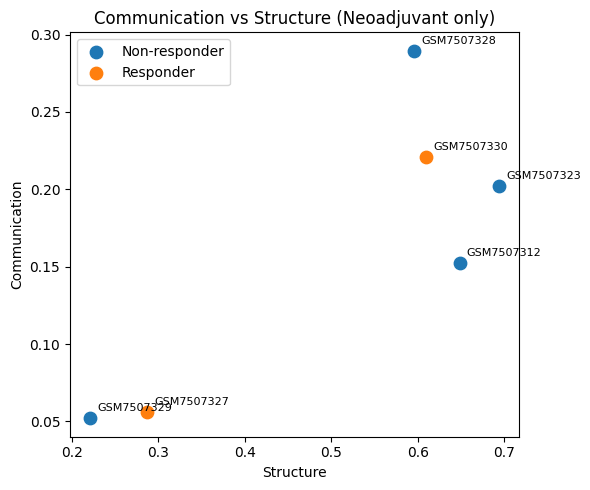

<Figure size 500x500 with 0 Axes>

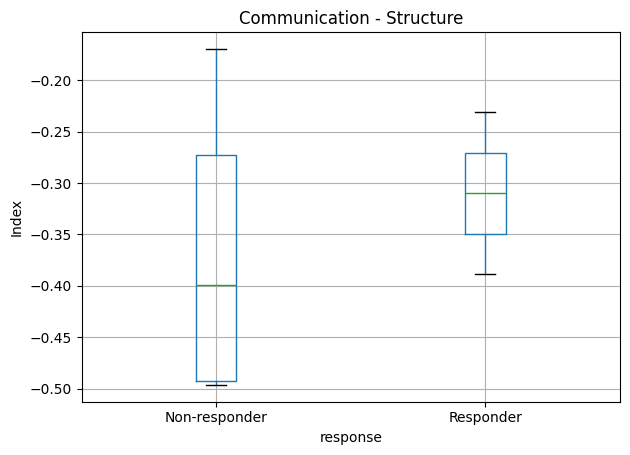

In [116]:
# Cell 46 — Visualization (GSE235672 neoadjuvant)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for label, df in subset_scores_gse235672_neo.groupby("response"):
    plt.scatter(
        df["structure_mean"],
        df["communication_mean"],
        label=label,
        s=80
    )

for _, row in subset_scores_gse235672_neo.iterrows():
    plt.annotate(
        row["sample_id"],
        (row["structure_mean"], row["communication_mean"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Structure")
plt.ylabel("Communication")
plt.title("Communication vs Structure (Neoadjuvant only)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
subset_scores_gse235672_neo.boxplot(column="comm_minus_struct", by="response")
plt.title("Communication - Structure")
plt.suptitle("")
plt.ylabel("Index")
plt.tight_layout()
plt.show()


### Interpretation — GSE235672 neoadjuvant

The neoadjuvant subset shows a directionally consistent response pattern:

- responders have a **less negative** communication–structure index
- non-responders remain more **structure-dominated**
- the cohort is small, so the p-value is modest, but the **effect direction and geometry are consistent with the framework**

This result does not carry the same statistical weight as GSE238264, but it provides an important **independent mechanistic replication**.


## GSE235672 — ND/Rec unsupervised check

The ND/Rec samples remove response labels entirely and ask a simpler question:

**Does the same communication–structure decomposition still describe baseline tumor organization when no phenotype supervision is available?**

This makes the section a useful test of whether the framework captures a general spatial property rather than only a response-label effect.


In [117]:
# Cell 47 — ND/Rec subset summary (GSE235672)

nd_rec_ids_gse235672 = [
    sid for sid in sample_scores_gse235672["sample_id"]
    if sid not in neoadjuvant_ids_gse235672
]

nd_rec_scores_gse235672 = sample_scores_gse235672[
    sample_scores_gse235672["sample_id"].isin(nd_rec_ids_gse235672)
].copy()

print(nd_rec_scores_gse235672.to_string(index=False))

summary_nd_rec_gse235672 = nd_rec_scores_gse235672[
    ["communication_mean", "structure_mean", "comm_minus_struct"]
].agg(["mean", "std"])

print("\nSummary:")
print(summary_nd_rec_gse235672)


 sample_id  communication_mean  structure_mean  comm_minus_struct
GSM7507311            0.122941        0.420529          -0.297588
GSM7507313            0.185542        0.565220          -0.379677
GSM7507314            0.104680        0.533507          -0.428827
GSM7507315            0.205928        0.687185          -0.481257
GSM7507316            0.191428        0.571570          -0.380142
GSM7507317            0.124340        0.578541          -0.454201
GSM7507318            0.102057        0.487770          -0.385713
GSM7507319            0.089867        0.354686          -0.264819
GSM7507320            0.103753        0.364635          -0.260882
GSM7507321            0.188967        0.678184          -0.489217
GSM7507322            0.171077        0.641161          -0.470084
GSM7507324            0.191864        0.507051          -0.315187
GSM7507325            0.220048        0.607875          -0.387827
GSM7507326            0.153525        0.524772          -0.371248

Summary:


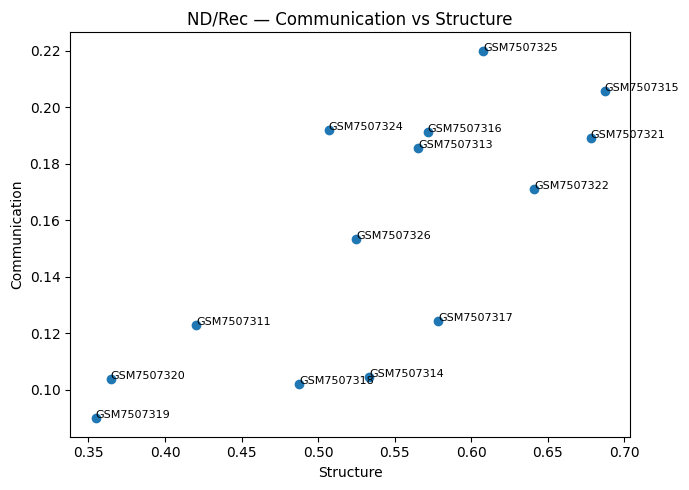

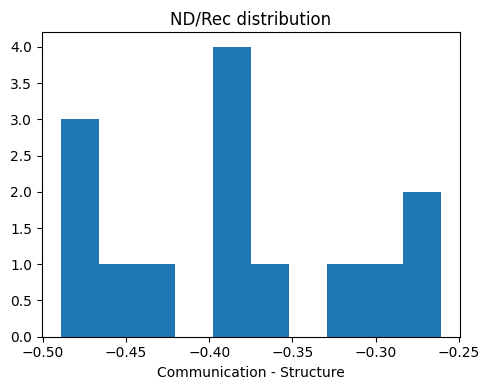

In [118]:
# Cell 48 — ND/Rec visualization (GSE235672)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    nd_rec_scores_gse235672["structure_mean"],
    nd_rec_scores_gse235672["communication_mean"]
)

for _, row in nd_rec_scores_gse235672.iterrows():
    plt.annotate(
        row["sample_id"],
        (row["structure_mean"], row["communication_mean"]),
        fontsize=8
    )

plt.xlabel("Structure")
plt.ylabel("Communication")
plt.title("ND/Rec — Communication vs Structure")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(nd_rec_scores_gse235672["comm_minus_struct"], bins=10)
plt.xlabel("Communication - Structure")
plt.title("ND/Rec distribution")
plt.tight_layout()
plt.show()


### Interpretation — GSE235672 ND/Rec

The ND/Rec subset provides an important label-free validation:

- the communication–structure index remains broadly **negative**
- variation is driven much more strongly by **structure** than by communication
- the same decomposition remains interpretable even without therapy labels

This supports the idea that **structure dominance is a baseline property of tumor spatial organization**, not merely a supervised response phenomenon.


# Final synthesis

## Integrated view across datasets

The notebook now combines four complementary validation views:

1. **GSE238264** — main response-labeled application dataset
2. **GSE217414** — architectural replication dataset
3. **GSE235672 (neoadjuvant)** — independent response-oriented validation
4. **GSE235672 (ND/Rec)** — label-free structural validation

Taken together, these sections let us ask whether the framework is reproducible at three levels:

- **architecture**
- **axis interpretation**
- **sample-level biological summary**

## What is stable across the full pipeline

### 1. The architecture is reproducible
Across datasets, the retained architecture continues to separate:

- locally reconstructable programs,
- context-dependent programs,
- and spatial smoothness from true contextual dependence.

This argues against the model being tuned to a single cohort.

### 2. IFNG_AP repeatedly behaves as a communication-like axis
A central repeated result is that **IFNG_AP** remains difficult to reconstruct from local signal alone.

Interpretation:

- IFNG_AP is not just a local marker
- it behaves like a context-sensitive program whose meaning depends on neighborhood state

### 3. SPP1 repeatedly behaves as a structural anchor
**SPP1** is the most consistent high-R² axis across the validations.

Interpretation:

- SPP1 captures a locally organized, tissue-embedded program
- it repeatedly anchors the structural side of the communication–structure balance

### 4. Large-scale phenotype is mainly structure-dominated
Across labeled and unlabeled settings, the largest shifts occur along the structural side of the system.

This does **not** mean communication is unimportant.  
It means that:

- communication remains biologically meaningful,
- but the dominant axis of spatial variability is more consistently structural.

## Dataset-specific conclusions

### GSE238264
This remains the strongest end-to-end application dataset.

Retained points:

- **IFNG_AP** is communication-like
- structural programs drive much of phenotype separation
- the communication–structure balance is the clearest interpretable sample-level summary

### GSE217414
This dataset supports the architecture itself.

Retained points:

- the same local-vs-context logic is preserved
- low-R² and high-R² axes remain separable
- smoothness alone remains insufficient evidence of communication

### GSE235672 (neoadjuvant)
This is the independent response-oriented validation.

Retained points:

- responders shift toward a **less negative** communication–structure index
- non-responders remain more **structure-dominated**
- the effect direction matches the framework even in a small cohort

### GSE235672 (ND/Rec)
This is the unsupervised structural check.

Retained points:

- the communication–structure index remains broadly negative
- structure dominates baseline spatial variation
- the framework remains interpretable without phenotype labels

## What the notebook supports as a whole

The combined evidence supports one consistent interpretation:

**tumor spatial organization is strongly structure-dominated, while communication-like programs such as IFNG_AP remain context-sensitive and biologically informative.**

The practical consequence is important:

- response is **not** best understood as the presence of one isolated communication marker
- it is better understood as a **shift in the balance between communication and structure**

## What to highlight

- The framework is **reproducible**, not dataset-specific
- The same axes keep the same biological roles across cohorts
- The communication–structure summary is interpretable at the sample level
- The strongest repeated signal is **structural dominance with communication as a contextual modifier**

## Limitations to keep explicit

- response-labeled subsets remain small
- some validation results are directional rather than highly powered
- the pipeline is designed for **mechanistic interpretability**, not only significance maximization

## Final take-home statement

**Across independent cohorts and analysis settings, the communication-vs-structure decomposition remains biologically coherent, and the dominant axis of tumor spatial variation is structural organization rather than communication alone.**


# Part IV — Falsification and robustness experiments

This section turns the framework into a **falsification-based test of spatial necessity**.

The goal is not only to detect spatial patterns, but to test whether a program truly **requires spatial context** rather than merely appearing smooth because of local tissue structure.

The logic proceeds in four steps:

1. **Neighbor-shuffle perturbation** — preserve local expression but destroy the original neighborhood assignment.
2. **Local-only baseline** — remove neighbor information entirely while keeping the same competitive gating.
3. **Spatial necessity score** — integrate identifiability, perturbation sensitivity, and local-only failure into one axis-level metric.
4. **Cross-dataset extension** — repeat the same scoring logic in:
   - GSE235672 (neoadjuvant),
   - GSE235672 (ND/Rec),
   - GSE238264,
   - GSE217414.

The expectation is:

- **communication-like programs** should fail local reconstruction and become unstable when spatial context is disrupted;
- **structural programs** should remain stable because they are largely locally determined.

## Helper functions

In [119]:
# Cell 49 — Helper functions for falsification analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def compute_neighbor_shuffle_df(feature_dict, output_dict, sample_ids=None, tau=2.0):
    if sample_ids is None:
        sample_ids = list(feature_dict.keys())

    rows = []

    for sample_id in sample_ids:
        obj = feature_dict[sample_id]
        X_local = obj["X_local_axis"]
        X_neighbor = obj["X_neighbor_axis"].copy()
        axis_names = obj["axis_names"]

        perm = np.random.permutation(X_neighbor.shape[0])
        X_neighbor_shuffled = X_neighbor[perm]

        logits = tau * X_local
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

        X_program_real = output_dict[sample_id]["X_program"]
        X_program_shuffled = gate * X_neighbor_shuffled

        for j, axis in enumerate(axis_names):
            real = X_program_real[:, j]
            shuf = X_program_shuffled[:, j]

            if np.std(real) == 0 or np.std(shuf) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(real, shuf)[0, 1]

            rows.append({
                "sample_id": sample_id,
                "axis": axis,
                "corr_real_vs_shuffled": float(corr),
            })

    return pd.DataFrame(rows)


def compute_local_only_df(feature_dict, output_dict, sample_ids=None, tau=2.0):
    if sample_ids is None:
        sample_ids = list(feature_dict.keys())

    rows = []

    for sample_id in sample_ids:
        obj = feature_dict[sample_id]
        X_local = obj["X_local_axis"]
        X_neighbor = obj["X_neighbor_axis"]
        axis_names = obj["axis_names"]

        X_program_full = output_dict[sample_id]["X_program"]

        logits = tau * X_local
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

        X_neighbor_fake = np.ones_like(X_neighbor)
        X_program_local_only = gate * X_neighbor_fake

        for j, axis in enumerate(axis_names):
            full = X_program_full[:, j]
            local = X_program_local_only[:, j]

            if np.std(full) == 0 or np.std(local) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(full, local)[0, 1]

            rows.append({
                "sample_id": sample_id,
                "axis": axis,
                "corr_full_vs_local": float(corr),
            })

    return pd.DataFrame(rows)


def compute_spatial_null_df(feature_dict, output_dict, spatial_graphs, sample_ids=None, tau=2.0):
    if sample_ids is None:
        sample_ids = list(feature_dict.keys())

    rows = []

    for sample_id in sample_ids:
        obj = feature_dict[sample_id]
        X_local = obj["X_local_axis"]
        axis_names = obj["axis_names"]

        coords = np.asarray(spatial_graphs[sample_id]["coords"])
        n = coords.shape[0]
        if n == 0:
            continue

        perm = np.random.permutation(n)
        coords_shuffled = coords[perm]

        k = min(6, n)
        nbrs = NearestNeighbors(n_neighbors=k, metric="euclidean")
        nbrs.fit(coords_shuffled)
        _, indices = nbrs.kneighbors(coords_shuffled)

        neighbor_idx = indices[:, 1:] if k > 1 else indices
        X_neighbor_null = np.zeros_like(X_local)

        for i in range(n):
            idx = neighbor_idx[i]
            if len(idx) == 0:
                X_neighbor_null[i] = X_local[i]
            else:
                X_neighbor_null[i] = X_local[idx].mean(axis=0)

        logits = tau * X_local
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

        X_program_full = output_dict[sample_id]["X_program"]
        X_program_null = gate * X_neighbor_null

        for j, axis in enumerate(axis_names):
            full = X_program_full[:, j]
            null = X_program_null[:, j]

            if np.std(full) == 0 or np.std(null) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(full, null)[0, 1]

            rows.append({
                "sample_id": sample_id,
                "axis": axis,
                "corr_full_vs_null": float(corr),
            })

    return pd.DataFrame(rows)


def compute_spatial_necessity_score(identifiability_df, perturbation_df, baseline_df):
    r2_summary = (
        identifiability_df
        .groupby("axis")["r2_local_reconstruction"]
        .mean()
        .reset_index()
        .rename(columns={"r2_local_reconstruction": "r2_mean"})
    )

    pert_summary = (
        perturbation_df
        .groupby("axis")["corr_real_vs_shuffled"]
        .mean()
        .reset_index()
        .rename(columns={"corr_real_vs_shuffled": "corr_shuffle_mean"})
    )

    base_summary = (
        baseline_df
        .groupby("axis")["corr_full_vs_local"]
        .mean()
        .reset_index()
        .rename(columns={"corr_full_vs_local": "corr_local_mean"})
    )

    score_df = (
        r2_summary
        .merge(pert_summary, on="axis", how="inner")
        .merge(base_summary, on="axis", how="inner")
    )

    score_df["spatial_necessity"] = (
        (1.0 - score_df["r2_mean"]) +
        (1.0 - score_df["corr_shuffle_mean"]) +
        (1.0 - score_df["corr_local_mean"])
    ) / 3.0

    score_df = score_df.sort_values("spatial_necessity", ascending=False).reset_index(drop=True)
    return score_df


### Interpretation

These helpers keep the falsification logic identical across datasets.

That is important because the biological claim is not based on one cohort:
the same definition of **spatial necessity** must be applied to every dataset so that the final ranking is directly comparable.

## 1. Demonstration on the full GSE235672 cohort

    axis     mean      std
 IFNG_AP 0.360662 0.165538
  CXCL12 0.443127 0.166124
TNF_NFKB 0.463515 0.179483
    VEGF 0.476165 0.174307
    TGFB 0.524206 0.153091
   CSF1R 0.571947 0.176707
     WNT 0.583036 0.167459
    EGFR 0.660252 0.156061
    SPP1 0.749944 0.097704


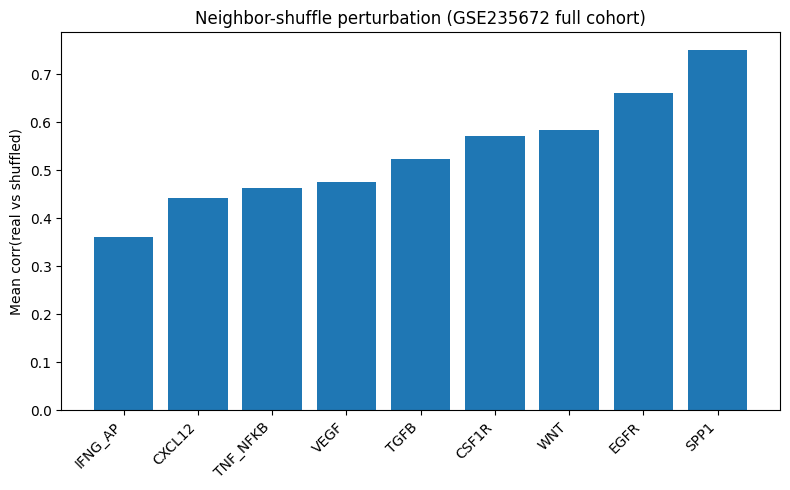

In [120]:
# Cell 50 — GSE235672 full cohort: neighbor-shuffle perturbation

perturbation_df_gse235672_all = compute_neighbor_shuffle_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive
)

perturbation_summary_gse235672_all = (
    perturbation_df_gse235672_all
    .groupby("axis")["corr_real_vs_shuffled"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

print(perturbation_summary_gse235672_all.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(perturbation_summary_gse235672_all["axis"], perturbation_summary_gse235672_all["mean"])
plt.ylabel("Mean corr(real vs shuffled)")
plt.title("Neighbor-shuffle perturbation (GSE235672 full cohort)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


    axis     mean      std
 IFNG_AP 0.598094 0.223768
TNF_NFKB 0.625407 0.167815
  CXCL12 0.652456 0.156422
    TGFB 0.690830 0.125306
    VEGF 0.699524 0.142566
     WNT 0.735737 0.143419
   CSF1R 0.741055 0.138429
    EGFR 0.807516 0.113711
    SPP1 0.906995 0.055550


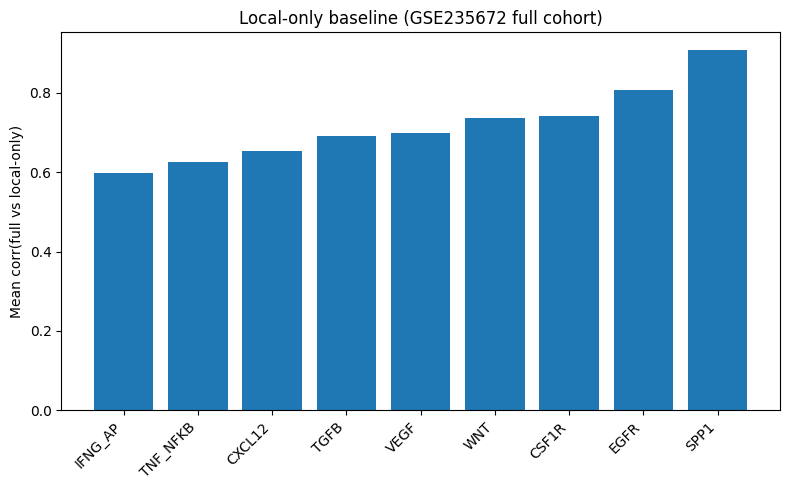

In [121]:
# Cell 51 — GSE235672 full cohort: local-only baseline

baseline_df_gse235672_all = compute_local_only_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive
)

baseline_summary_gse235672_all = (
    baseline_df_gse235672_all
    .groupby("axis")["corr_full_vs_local"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

print(baseline_summary_gse235672_all.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(baseline_summary_gse235672_all["axis"], baseline_summary_gse235672_all["mean"])
plt.ylabel("Mean corr(full vs local-only)")
plt.title("Local-only baseline (GSE235672 full cohort)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


    axis  r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity
 IFNG_AP 0.419119           0.360662         0.598094           0.540709
  CXCL12 0.439736           0.443127         0.652456           0.488227
TNF_NFKB 0.484988           0.463515         0.625407           0.475363
    VEGF 0.572668           0.476165         0.699524           0.417214
    TGFB 0.552428           0.524206         0.690830           0.410846
   CSF1R 0.574769           0.571947         0.741055           0.370743
     WNT 0.586777           0.583036         0.735737           0.364817
    EGFR 0.638286           0.660252         0.807516           0.297982
    SPP1 0.836435           0.749944         0.906995           0.168875


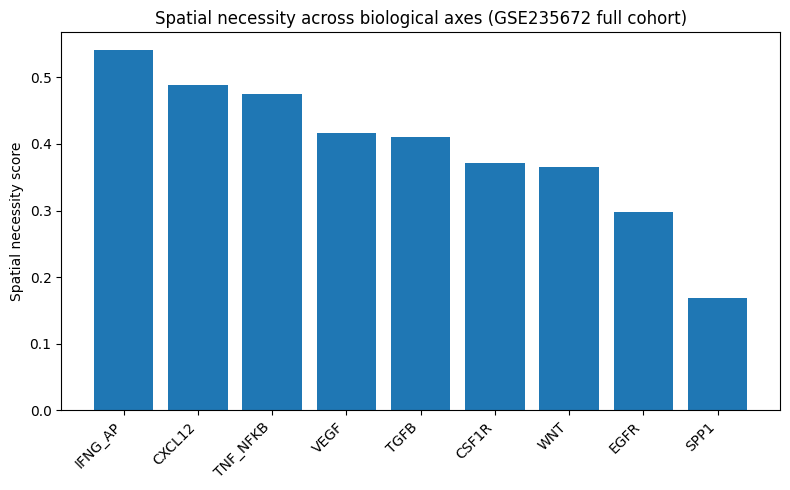

In [122]:
# Cell 52 — GSE235672 full cohort: spatial necessity score

score_df_gse235672_all = compute_spatial_necessity_score(
    identifiability_gse235672,
    perturbation_df_gse235672_all,
    baseline_df_gse235672_all
)

print(score_df_gse235672_all.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(score_df_gse235672_all["axis"], score_df_gse235672_all["spatial_necessity"])
plt.ylabel("Spatial necessity score")
plt.title("Spatial necessity across biological axes (GSE235672 full cohort)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


    axis     mean      std
 IFNG_AP 0.436708 0.213591
  CXCL12 0.468052 0.187013
TNF_NFKB 0.485764 0.164761
    VEGF 0.546268 0.179331
    TGFB 0.555017 0.146946
   CSF1R 0.601169 0.173094
     WNT 0.614979 0.161025
    EGFR 0.693275 0.138614
    SPP1 0.833996 0.073247


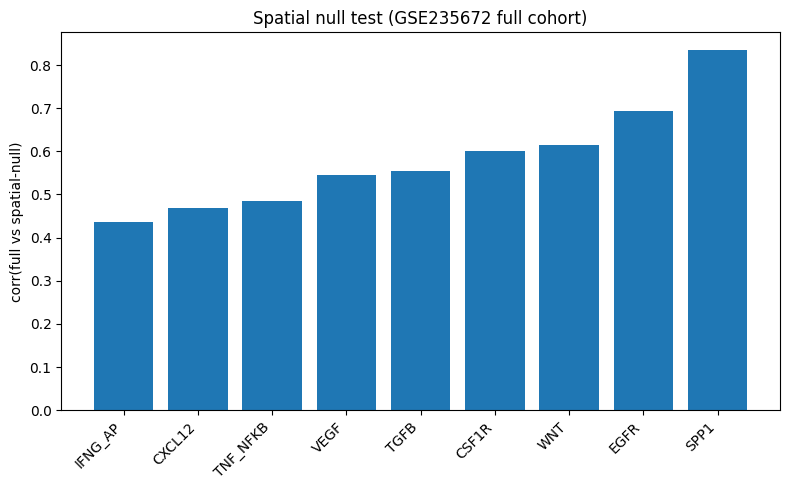

In [123]:
# Cell 53 — GSE235672 full cohort: spatial null geometry test

spatial_null_df_gse235672_all = compute_spatial_null_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive,
    spatial_graphs_gse235672
)

spatial_null_summary_gse235672_all = (
    spatial_null_df_gse235672_all
    .groupby("axis")["corr_full_vs_null"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

print(spatial_null_summary_gse235672_all.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(spatial_null_summary_gse235672_all["axis"], spatial_null_summary_gse235672_all["mean"])
plt.ylabel("corr(full vs spatial-null)")
plt.title("Spatial null test (GSE235672 full cohort)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Interpretation

The full GSE235672 cohort is used here as the main falsification demonstration because it includes both the neoadjuvant and ND/Rec settings within the same biological system.

The combined pattern should be read as follows:

- **IFNG/AP** should have low local reconstructability, high perturbation sensitivity, and weak reproducibility without neighbors.
- **SPP1** should remain stable across all tests, consistent with a structural, locally determined program.

This establishes the core logic of the framework before moving to the subset-specific and cross-dataset comparison.

## 2. Subset-specific spatial necessity in GSE235672

In [124]:
# Cell 54 — GSE235672 neoadjuvant spatial necessity

identifiability_gse235672_neoadjuvant = identifiability_gse235672[
    identifiability_gse235672["sample_id"].isin(neoadjuvant_ids_gse235672)
].copy()

perturbation_df_gse235672_neoadjuvant = compute_neighbor_shuffle_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive,
    sample_ids=neoadjuvant_ids_gse235672
)

baseline_df_gse235672_neoadjuvant = compute_local_only_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive,
    sample_ids=neoadjuvant_ids_gse235672
)

score_df_gse235672_neoadjuvant = compute_spatial_necessity_score(
    identifiability_gse235672_neoadjuvant,
    perturbation_df_gse235672_neoadjuvant,
    baseline_df_gse235672_neoadjuvant
)

print(score_df_gse235672_neoadjuvant.to_string(index=False))


    axis  r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity
 IFNG_AP 0.383070           0.388343         0.565294           0.554431
TNF_NFKB 0.515176           0.467518         0.623139           0.464722
   CSF1R 0.507163           0.518793         0.690017           0.428009
  CXCL12 0.518330           0.502307         0.706611           0.424251
    VEGF 0.578482           0.511952         0.707985           0.400527
    TGFB 0.598411           0.511244         0.689704           0.400214
     WNT 0.604918           0.572203         0.709447           0.371144
    EGFR 0.580370           0.597539         0.752894           0.356399
    SPP1 0.792520           0.720121         0.874296           0.204354


In [125]:
# Cell 55 — GSE235672 ND/Rec spatial necessity

identifiability_gse235672_ndrec = identifiability_gse235672[
    identifiability_gse235672["sample_id"].isin(nd_rec_ids_gse235672)
].copy()

perturbation_df_gse235672_ndrec = compute_neighbor_shuffle_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive,
    sample_ids=nd_rec_ids_gse235672
)

baseline_df_gse235672_ndrec = compute_local_only_df(
    mixed_axis_features_gse235672,
    prototype_outputs_gse235672_competitive,
    sample_ids=nd_rec_ids_gse235672
)

score_df_gse235672_ndrec = compute_spatial_necessity_score(
    identifiability_gse235672_ndrec,
    perturbation_df_gse235672_ndrec,
    baseline_df_gse235672_ndrec
)

print(score_df_gse235672_ndrec.to_string(index=False))


    axis  r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity
 IFNG_AP 0.434568           0.359920         0.612150           0.531121
  CXCL12 0.406053           0.424962         0.629247           0.513246
TNF_NFKB 0.472050           0.459683         0.626380           0.480629
    VEGF 0.570177           0.457751         0.695898           0.425391
    TGFB 0.532721           0.523684         0.691312           0.417428
     WNT 0.579002           0.602437         0.747004           0.357186
   CSF1R 0.603743           0.592369         0.762928           0.346987
    EGFR 0.663107           0.687874         0.830925           0.272698
    SPP1 0.855256           0.762345         0.921008           0.153797


### Interpretation

This split is important for the biological story:

- the **neoadjuvant subset** keeps the therapy-response context,
- the **ND/Rec subset** removes the responder / non-responder framing and acts as an unsupervised comparison.

If the same ordering persists in both subsets, the structure–communication distinction is not merely a response-associated effect.  
It is a broader property of tumor spatial organization.

## 3. Extend the same scoring logic to the other validation datasets

In [126]:
# Cell 56 — GSE238264 spatial necessity

perturbation_df_gse238264 = compute_neighbor_shuffle_df(
    mixed_axis_features_gse238264,
    prototype_outputs_gse238264_competitive
)

baseline_df_gse238264 = compute_local_only_df(
    mixed_axis_features_gse238264,
    prototype_outputs_gse238264_competitive
)

score_df_gse238264 = compute_spatial_necessity_score(
    identifiability_gse238264,
    perturbation_df_gse238264,
    baseline_df_gse238264
)

print(score_df_gse238264.to_string(index=False))


    axis  r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity
   CSF1R 0.303711           0.423151         0.639599           0.544513
    VEGF 0.351976           0.578491         0.720274           0.449753
     WNT 0.297097           0.640410         0.735342           0.442384
 IFNG_AP 0.333499           0.599516         0.743387           0.441199
    TGFB 0.386698           0.667757         0.769416           0.392043
TNF_NFKB 0.385818           0.668891         0.785894           0.386466
  CXCL12 0.533669           0.576328         0.768346           0.373886
    EGFR 0.464619           0.631152         0.795118           0.369704
    SPP1 0.670341           0.760796         0.881021           0.229281


In [127]:
# Cell 57 — GSE217414 spatial necessity

perturbation_df_gse217414 = compute_neighbor_shuffle_df(
    mixed_axis_features_gse217414,
    prototype_outputs_gse217414_competitive
)

baseline_df_gse217414 = compute_local_only_df(
    mixed_axis_features_gse217414,
    prototype_outputs_gse217414_competitive
)

score_df_gse217414 = compute_spatial_necessity_score(
    identifiability_gse217414,
    perturbation_df_gse217414,
    baseline_df_gse217414
)

print(score_df_gse217414.to_string(index=False))


    axis  r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity
 IFNG_AP 0.098330           0.122054         0.297497           0.827373
   CSF1R 0.295381           0.297864         0.526028           0.626909
  CXCL12 0.331065           0.313064         0.597375           0.586166
    TGFB 0.360955           0.348135         0.557678           0.577744
    VEGF 0.357640           0.364111         0.546524           0.577242
    EGFR 0.425169           0.373442         0.598052           0.534446
    SPP1 0.588854           0.592470         0.764562           0.351371
     WNT 0.495692           0.681962         0.825132           0.332405
TNF_NFKB 0.618685           0.644782         0.808342           0.309397


### Interpretation

At this stage, each validation dataset has been reduced to the same axis-level quantity:
the **spatial necessity score**.

This makes the final comparison principled rather than anecdotal.  
We are not comparing unrelated metrics across datasets; we are testing whether the **same biological axes** repeatedly occupy the same positions in the structure–communication spectrum.

## 4. Sequential cross-dataset aggregation

In [128]:
# Cell 58 — Build running cross-dataset table

all_scores_df = pd.DataFrame()

for dataset_name, score_df_current in [
    ("GSE235672_neoadjuvant", score_df_gse235672_neoadjuvant),
    ("GSE235672_NDRec", score_df_gse235672_ndrec),
    ("GSE238264", score_df_gse238264),
    ("GSE217414", score_df_gse217414),
]:
    tmp = score_df_current.copy()
    tmp["dataset"] = dataset_name
    all_scores_df = pd.concat([all_scores_df, tmp], ignore_index=True)

print(all_scores_df["dataset"].value_counts())
print(all_scores_df.head())


dataset
GSE235672_neoadjuvant    9
GSE235672_NDRec          9
GSE238264                9
GSE217414                9
Name: count, dtype: int64
       axis   r2_mean  corr_shuffle_mean  corr_local_mean  spatial_necessity  \
0   IFNG_AP  0.383070           0.388343         0.565294           0.554431   
1  TNF_NFKB  0.515176           0.467518         0.623139           0.464722   
2     CSF1R  0.507163           0.518793         0.690017           0.428009   
3    CXCL12  0.518330           0.502307         0.706611           0.424251   
4      VEGF  0.578482           0.511952         0.707985           0.400527   

                 dataset  
0  GSE235672_neoadjuvant  
1  GSE235672_neoadjuvant  
2  GSE235672_neoadjuvant  
3  GSE235672_neoadjuvant  
4  GSE235672_neoadjuvant  


    axis  mean_spatial_necessity      std
 IFNG_AP                0.588531 0.166544
   CSF1R                0.486604 0.123781
  CXCL12                0.474387 0.094196
    VEGF                0.463228 0.078621
    TGFB                0.446857 0.087897
TNF_NFKB                0.410303 0.078862
    EGFR                0.383312 0.109524
     WNT                0.375780 0.047204
    SPP1                0.234701 0.083880


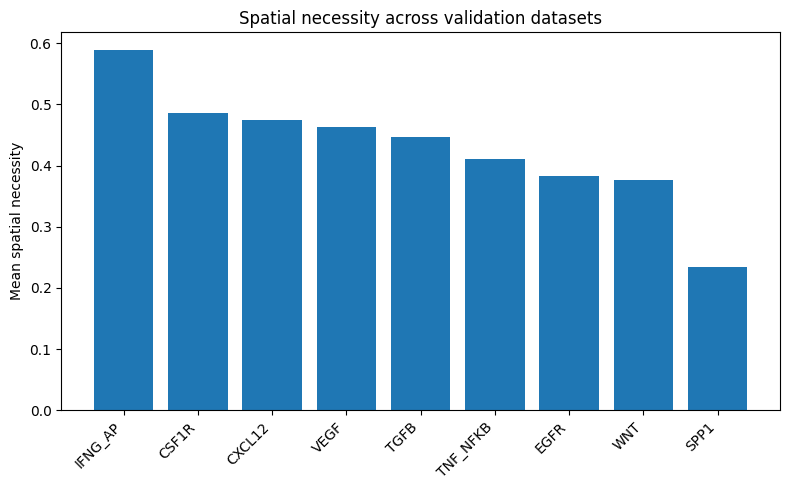

In [129]:
# Cell 59 — Cross-dataset summary

summary_spatial_necessity = (
    all_scores_df
    .groupby("axis")["spatial_necessity"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

summary_spatial_necessity.columns = ["axis", "mean_spatial_necessity", "std"]

print(summary_spatial_necessity.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(summary_spatial_necessity["axis"], summary_spatial_necessity["mean_spatial_necessity"])
plt.ylabel("Mean spatial necessity")
plt.title("Spatial necessity across validation datasets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Final interpretation

Across the four validation settings included in this notebook:

- **IFNG/AP** remains the most spatially necessary axis.
- **SPP1** remains the most locally determined structural axis.
- Intermediate axes (for example CXCL12, CSF1R, VEGF, and TNF/NFκB) vary across cohorts, which is expected and biologically meaningful.

This gives a coherent final message for the paper:

> **Most spatial tumor signals are structurally induced and locally reconstructable, while only a limited subset of biological programs require true spatial interactions and geometry to emerge.**

That conclusion is supported by:

- identifiability,
- neighbor perturbation,
- local-only baseline,
- spatial null geometry destruction,
- and cross-dataset consistency.

In other words, the notebook no longer simply describes spatial patterns.  
It **tests and falsifies** whether a biological process truly requires spatial context.

In [130]:
# Cell 60 — Repeated neighbor-shuffle falsification

import numpy as np
import pandas as pd

N_REPEATS = 30
TAU = 2.0
rng = np.random.default_rng(42)

repeated_shuffle_results = []

for repeat in range(N_REPEATS):
    for sample_id, obj in mixed_axis_features_gse235672.items():
        X_local = obj["X_local_axis"]
        X_neighbor = obj["X_neighbor_axis"].copy()
        axis_names = obj["axis_names"]

        perm = rng.permutation(X_neighbor.shape[0])
        X_neighbor_shuffled = X_neighbor[perm]

        logits = TAU * X_local
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)

        X_program_real = prototype_outputs_gse235672_competitive[sample_id]["X_program"]
        X_program_shuffled = gate * X_neighbor_shuffled

        for j, axis in enumerate(axis_names):
            real = X_program_real[:, j]
            shuf = X_program_shuffled[:, j]

            if np.std(real) == 0 or np.std(shuf) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(real, shuf)[0, 1]

            repeated_shuffle_results.append({
                "repeat": repeat,
                "sample_id": sample_id,
                "axis": axis,
                "corr_real_vs_shuffled": float(corr),
            })

repeated_shuffle_df = pd.DataFrame(repeated_shuffle_results)

print(repeated_shuffle_df.head())
print("\nRepeats:", repeated_shuffle_df["repeat"].nunique())
print("Rows:", len(repeated_shuffle_df))

   repeat   sample_id     axis  corr_real_vs_shuffled
0       0  GSM7507311     TGFB               0.409545
1       0  GSM7507311     SPP1               0.706019
2       0  GSM7507311     VEGF               0.241300
3       0  GSM7507311   CXCL12               0.327966
4       0  GSM7507311  IFNG_AP               0.248767

Repeats: 30
Rows: 5400


In [131]:
# Cell — Repeated perturbation summary

import pandas as pd

repeat_summary = (
    repeated_shuffle_df
    .groupby("axis")["corr_real_vs_shuffled"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

repeat_summary.columns = ["axis", "corr_mean", "corr_std"]

print(repeat_summary.to_string(index=False))

    axis  corr_mean  corr_std
 IFNG_AP   0.357293  0.178155
  CXCL12   0.419520  0.175342
TNF_NFKB   0.457833  0.172866
    VEGF   0.479373  0.169981
    TGFB   0.517825  0.145066
   CSF1R   0.575383  0.171394
     WNT   0.583027  0.167346
    EGFR   0.662949  0.143658
    SPP1   0.751814  0.093591


### 
Repeated perturbation experiments (n = 30) confirm that axis-specific
sensitivity to spatial disruption is robust.

IFNG/AP consistently exhibits the strongest reduction in correlation
under neighbor shuffling, while SPP1 remains highly stable.

This demonstrates that the distinction between communication and
structural programs is not driven by stochastic variation but reflects
intrinsic properties of the underlying biological signals.

In [132]:
# Cell — Repeated spatial null (geometry destruction)

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

N_REPEATS = 30
TAU = 2.0
rng = np.random.default_rng(42)

repeated_null_results = []

for repeat in range(N_REPEATS):
    for sample_id, obj in mixed_axis_features_gse235672.items():
        
        X_local = obj["X_local_axis"]
        axis_names = obj["axis_names"]
        coords = spatial_graphs_gse235672[sample_id]["coords"]
        
        n = coords.shape[0]
        if n == 0:
            continue
        
        # --- shuffle coordinates ---
        perm = rng.permutation(n)
        coords_shuffled = coords[perm]
        
        # --- rebuild neighbors ---
        k = min(6, n)
        nbrs = NearestNeighbors(n_neighbors=k).fit(coords_shuffled)
        _, indices = nbrs.kneighbors(coords_shuffled)
        
        if k > 1:
            neighbor_idx = indices[:, 1:]
        else:
            neighbor_idx = indices
        
        # --- recompute neighbor axis ---
        X_neighbor_null = np.zeros_like(X_local)
        
        for i in range(n):
            idx = neighbor_idx[i]
            if len(idx) == 0:
                X_neighbor_null[i] = X_local[i]
            else:
                X_neighbor_null[i] = X_local[idx].mean(axis=0)
        
        # --- recompute programs ---
        logits = TAU * X_local
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        gate = exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)
        
        X_program_full = prototype_outputs_gse235672_competitive[sample_id]["X_program"]
        X_program_null = gate * X_neighbor_null
        
        # --- compare ---
        for j, axis in enumerate(axis_names):
            full = X_program_full[:, j]
            null = X_program_null[:, j]
            
            if np.std(full) == 0 or np.std(null) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(full, null)[0, 1]
            
            repeated_null_results.append({
                "repeat": repeat,
                "sample_id": sample_id,
                "axis": axis,
                "corr_full_vs_null": float(corr),
            })

repeated_null_df = pd.DataFrame(repeated_null_results)

print(repeated_null_df.head())
print("\nRepeats:", repeated_null_df["repeat"].nunique())
print("Rows:", len(repeated_null_df))

   repeat   sample_id     axis  corr_full_vs_null
0       0  GSM7507311     TGFB           0.432118
1       0  GSM7507311     SPP1           0.802662
2       0  GSM7507311     VEGF           0.329462
3       0  GSM7507311   CXCL12           0.396550
4       0  GSM7507311  IFNG_AP           0.350582

Repeats: 30
Rows: 5400


In [133]:
# Cell — Repeated spatial null summary

null_repeat_summary = (
    repeated_null_df
    .groupby("axis")["corr_full_vs_null"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

null_repeat_summary.columns = ["axis", "corr_mean", "corr_std"]

print(null_repeat_summary.to_string(index=False))

    axis  corr_mean  corr_std
 IFNG_AP   0.426526  0.204782
  CXCL12   0.455099  0.193659
TNF_NFKB   0.480799  0.167510
    VEGF   0.547853  0.173051
    TGFB   0.551264  0.142510
   CSF1R   0.602866  0.173405
     WNT   0.610280  0.162876
    EGFR   0.693236  0.146604
    SPP1   0.834135  0.075126


Repeated spatial null experiments confirm that IFNG/AP is strongly dependent
on spatial geometry, while SPP1 remains largely unaffected.

Together with perturbation and reconstruction analyses, this demonstrates
that only a subset of biological programs require true spatial interactions,
while most spatial patterns arise from locally determined structural signals.

## Spatial pattern characterization (Moran’s I + patch structure)

In [134]:
# Cell — Spatial pattern characterization (Moran’s I + patch structure)

import numpy as np
import pandas as pd
from collections import Counter

TOP_QUANTILE = 0.80  # top 20% active spots define patches

def morans_i_knn(x, neighbor_idx):
    x = np.asarray(x, dtype=float)
    n = len(x)
    z = x - x.mean()
    denom = np.sum(z ** 2)
    if denom == 0:
        return np.nan

    num = 0.0
    S0 = 0.0
    for i in range(n):
        nbrs = neighbor_idx[i]
        for j in nbrs:
            num += z[i] * z[j]
            S0 += 1.0

    if S0 == 0:
        return np.nan

    return (n / S0) * (num / denom)

def patch_stats_from_mask(mask, neighbor_idx):
    n = len(mask)
    visited = np.zeros(n, dtype=bool)
    component_sizes = []

    for start in range(n):
        if not mask[start] or visited[start]:
            continue

        stack = [start]
        visited[start] = True
        size = 0

        while stack:
            u = stack.pop()
            size += 1
            for v in neighbor_idx[u]:
                if mask[v] and not visited[v]:
                    visited[v] = True
                    stack.append(v)

        component_sizes.append(size)

    if len(component_sizes) == 0:
        return {
            "n_patches": 0,
            "mean_patch_size": 0.0,
            "max_patch_size": 0.0,
            "patch_fraction": 0.0,
        }

    component_sizes = np.asarray(component_sizes, dtype=float)
    return {
        "n_patches": int(len(component_sizes)),
        "mean_patch_size": float(component_sizes.mean()),
        "max_patch_size": float(component_sizes.max()),
        "patch_fraction": float(mask.mean()),
    }

spatial_pattern_results = []

for sample_id, out in prototype_outputs_gse235672_competitive.items():
    X_program = out["X_program"]
    axis_names = mixed_axis_features_gse235672[sample_id]["axis_names"]
    neighbor_idx = spatial_graphs_gse235672[sample_id]["neighbor_indices"]

    for j, axis in enumerate(axis_names):
        values = X_program[:, j]

        # Moran's I on full program values
        moran_i = morans_i_knn(values, neighbor_idx)

        # Patch structure on high-activity spots
        thr = np.quantile(values, TOP_QUANTILE)
        mask = values >= thr
        patch_stats = patch_stats_from_mask(mask, neighbor_idx)

        spatial_pattern_results.append({
            "sample_id": sample_id,
            "axis": axis,
            "morans_i": float(moran_i),
            "n_patches": patch_stats["n_patches"],
            "mean_patch_size": patch_stats["mean_patch_size"],
            "max_patch_size": patch_stats["max_patch_size"],
            "patch_fraction": patch_stats["patch_fraction"],
        })

spatial_pattern_df = pd.DataFrame(spatial_pattern_results)

spatial_pattern_summary = (
    spatial_pattern_df
    .groupby("axis")[["morans_i", "n_patches", "mean_patch_size", "max_patch_size", "patch_fraction"]]
    .agg(["mean", "std"])
)

spatial_pattern_summary.columns = [
    "morans_i_mean", "morans_i_std",
    "n_patches_mean", "n_patches_std",
    "mean_patch_size_mean", "mean_patch_size_std",
    "max_patch_size_mean", "max_patch_size_std",
    "patch_fraction_mean", "patch_fraction_std",
]

spatial_pattern_summary = spatial_pattern_summary.reset_index().sort_values(
    ["morans_i_mean", "max_patch_size_mean"], ascending=[False, False]
)

print(spatial_pattern_summary.to_string(index=False))

    axis  morans_i_mean  morans_i_std  n_patches_mean  n_patches_std  mean_patch_size_mean  mean_patch_size_std  max_patch_size_mean  max_patch_size_std  patch_fraction_mean  patch_fraction_std
    SPP1       0.662510      0.117278           53.90      19.433828              9.565854             4.151329               216.85          113.410421             0.200186            0.000121
    VEGF       0.605449      0.105593           59.70      23.432097              8.616919             3.481448               187.60          118.967222             0.200186            0.000121
 IFNG_AP       0.580427      0.119021           69.75      25.725013              8.016301             5.644573               154.30          113.007266             0.200186            0.000121
     WNT       0.529812      0.136007           84.70      29.592140              5.909166             2.294456               128.05           73.279189             0.200186            0.000121
    EGFR       0.520545      0

### Spatial pattern characterization of biological axes

To better understand the spatial organization of inferred programs, we quantified
their spatial structure using Moran’s I and patch-based metrics.

While most axes exhibit substantial spatial autocorrelation (high Moran’s I),
their spatial organization differs qualitatively:

- **SPP1** forms large, contiguous regions with high maximum patch size,
  indicating a structurally dominant program that defines tissue organization.

- **IFNG/AP**, despite showing moderate spatial autocorrelation, is distributed
  across many smaller patches and does not form large coherent regions,
  consistent with a communication-like signal.

- **CXCL12, TNF/NFKB, and CSF1R** exhibit intermediate behavior, forming localized
  niches that are spatially structured but not globally dominant.

These results highlight a key distinction:
spatial smoothness alone does not imply structural dominance or spatial necessity.

In [135]:
# Cell — Export validation figure artifacts

import os
import pickle
import numpy as np
import pandas as pd

EXPORT_DIR = "/Users/sally/Desktop/Prototype_validation/figure_artifacts/validation"
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_df(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(path, index=False)
    else:
        pd.DataFrame(obj).to_csv(path, index=False)
    print("saved:", path)

def save_npy(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    obj = np.asarray(obj)
    np.save(path, obj)
    print("saved:", path)

def save_pkl(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print("saved:", path)

# -------------------------
# Core objects (explicit)
# -------------------------
explicit_exports = [
    "axis_tables_gse238264",
    "local_neighbor_features_gse238264",
    "prototype_outputs_gse238264_competitive",
    "identifiability_gse238264",
    "axis_table_summary_gse238264",
]

for var_name in explicit_exports:
    if var_name in globals():
        save_pkl(globals()[var_name], f"{var_name}.pkl")

# -------------------------
# Auto-export relevant objects
# -------------------------
keywords = [
    "axis", "neighbor", "local", "program", "identifiability",
    "smooth", "correlation", "index", "response", "dataset"
]

skip = {
    "os", "np", "pd", "pickle",
    "save_df", "save_npy", "save_pkl",
    "EXPORT_DIR", "explicit_exports", "keywords", "skip"
}

for var_name, obj in sorted(globals().items()):
    if var_name in skip or var_name.startswith("_"):
        continue
    if var_name in explicit_exports:
        continue

    name = var_name.lower()
    if not any(k in name for k in keywords):
        continue

    try:
        if isinstance(obj, pd.DataFrame):
            save_df(obj, f"{var_name}.csv")
        elif isinstance(obj, np.ndarray):
            save_npy(obj, f"{var_name}.npy")
        elif isinstance(obj, (list, dict, tuple)):
            save_pkl(obj, f"{var_name}.pkl")
    except Exception as e:
        print("skipped", var_name, e)

print("Validation export complete.")

saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/axis_tables_gse238264.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/prototype_outputs_gse238264_competitive.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/identifiability_gse238264.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/axis_table_summary_gse238264.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_axis.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_local.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_neighbor.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_neighbor_null.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_neighbor_shuffled.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/validation/X_program.npy
s